# TCC Parte 3 - Análise dos Resultados

No notebook anterior, cada modelo passou pelo loop treino/teste 30 vezes, variando a cada vez a semente aleatória porém assumindo apenas valores fixos pré-determinados. Isso não é seed hacking, isso serve apenas para contabilizar a aleatoriedade inerente a inicialização de pesos em modelos de Redes Neurais e no split de nós em Random Forest. Aqui os resultados são analisados em grande parte considerando uma distribuição das métricas através dessas 30 execuções

In [103]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.patches as mpatches

from scipy.stats import pearsonr
from scikit_posthocs import posthoc_dunn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from modules.financial_helpers import *
from modules.dataframe_helpers import get_sharpe_series_from_results, get_metric_distribution_from_results
from modules.chart_helpers import *
from modules.statistical_tests import *

In [2]:
with open("results/lstm_01", "rb") as f:
    results_lstm_1 = pickle.load(f)

with open("results/gru_01", "rb") as f:
    results_gru_1 = pickle.load(f)

with open("results/rf_01", "rb") as f:
    results_rf_1 = pickle.load(f)

with open("results/rg_01", "rb") as f:
    results_rg_1 = pickle.load(f)

with open("results/rnn_01", "rb") as f:
    results_rnn_1 = pickle.load(f)

daily_returns = pd.read_csv("data/buy_and_hold_df.csv")
daily_returns['Date'] = pd.to_datetime(daily_returns['Date'], format='%Y-%m-%d')
daily_returns.set_index('Date', inplace=True)

In [3]:
lstm_sharpes_1 = get_sharpe_series_from_results(results_lstm_1, daily_returns)
gru_sharpes_1 = get_sharpe_series_from_results(results_gru_1, daily_returns)
rf_sharpes_1 = get_sharpe_series_from_results(results_rf_1, daily_returns)
rnn_sharpes_1 = get_sharpe_series_from_results(results_rnn_1, daily_returns)
rg_sharpes_1 = get_sharpe_series_from_results(results_rg_1, daily_returns)

In [4]:
best_results_lstm_01, cuml_perf_lstm_01, max_sharpe_lstm_01, best_exp_idx_lstm = find_best_experiment(results_lstm_1, daily_returns)
best_results_gru_1, cuml_perf_gru_1, max_sharpe_gru_1, best_exp_idx_gru = find_best_experiment(results_gru_1, daily_returns)
best_results_rnn_1, cuml_perf_rnn_1, max_sharpe_rnn_1, best_exp_idx_rnn = find_best_experiment(results_rnn_1, daily_returns)
best_results_rf_1, cuml_perf_rf_1, max_sharpe_rf_1, best_exp_idx_rf = find_best_experiment(results_rf_1, daily_returns)
best_results_rg_1, cuml_perf_rg_1, max_sharpe_rg_1, best_exp_idx_rg = find_best_experiment(results_rg_1, daily_returns)

Selected exp number 25
Selected exp number 25
Selected exp number 8
Selected exp number 28
Selected exp number 26


### Distribuição de Sharpe Ratios - INCLUIR

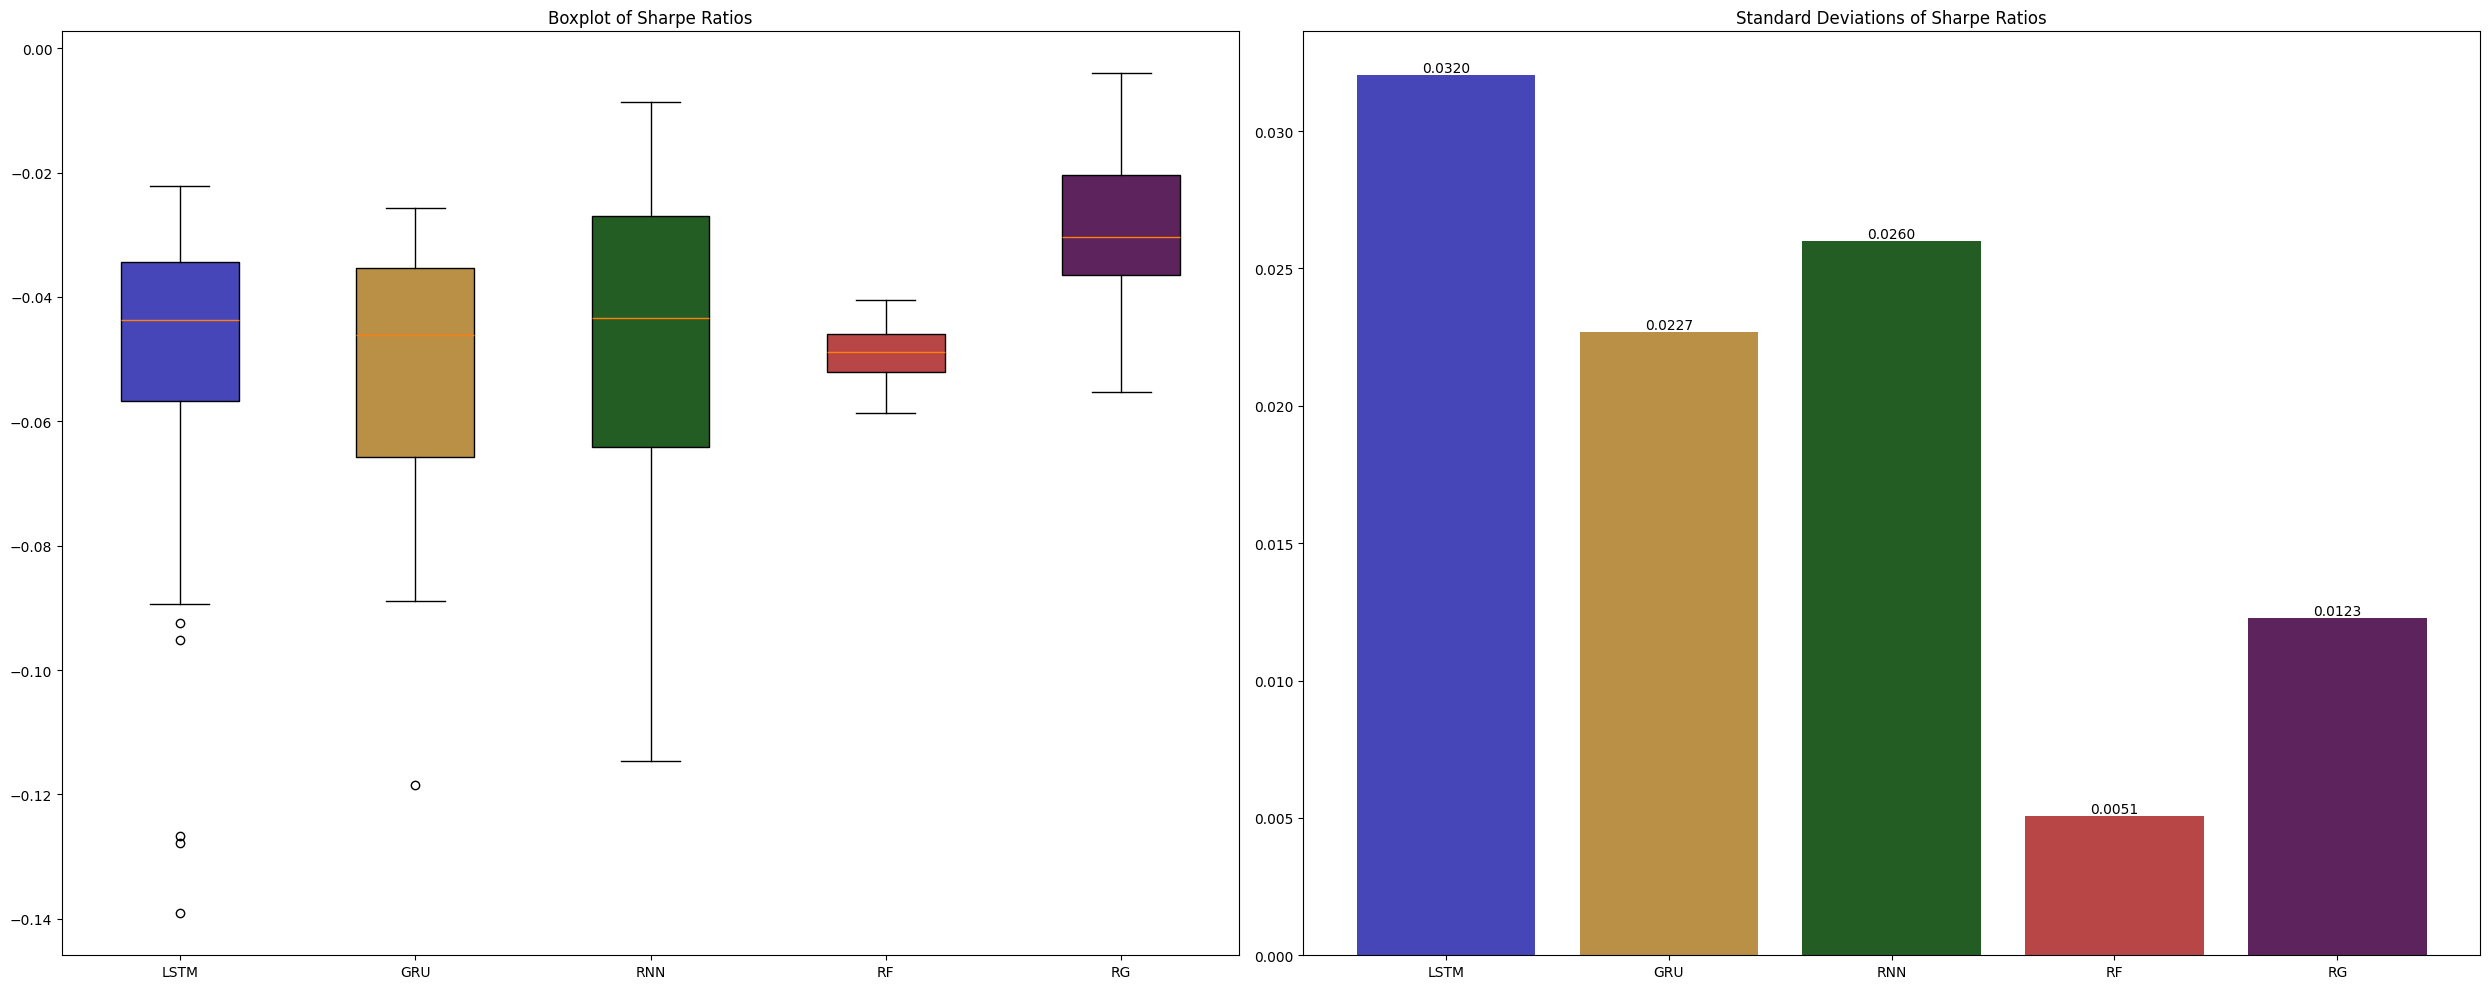

In [5]:
plot_distribution_and_stddev([
    lstm_sharpes_1,
    gru_sharpes_1,
    rnn_sharpes_1,
    rf_sharpes_1,
    rg_sharpes_1
],
"Sharpe Ratios"
)

In [6]:
print_statistics_table_for_series([
    lstm_sharpes_1,
    gru_sharpes_1,
    rnn_sharpes_1,
    rf_sharpes_1,
    rg_sharpes_1
])

+-------+-----------------------+-----------------------+-----------------------+----------------------+----------------------+----------------------+
| model |          mean         |         median        |          max          |         min          |        stddev        |      full range      |
+-------+-----------------------+-----------------------+-----------------------+----------------------+----------------------+----------------------+
|  LSTM |  -0.05469278746345534 |  -0.04364746671094107 |  -0.02219927972908448 | -0.13911284761431314 | 0.03202782447080706  | 0.11691356788522866  |
|  GRU  |  -0.05260069799253855 |  -0.04619863207536368 |  -0.02574279096131124 | -0.11852371813414758 | 0.022672410132317473 | 0.09278092717283634  |
|  RNN  |  -0.04813754493467541 | -0.043311056769234635 | -0.008592267033706113 | -0.11467834127175293 | 0.02600443290836783  | 0.10608607423804682  |
|   RF  |  -0.04900841127707337 |  -0.04892510602221292 | -0.040461685796560384 | -0.058652237

Nenhum modelo chegou a atingir um sharpe ratio positivo, significa que apesar de obter retornos positivos, nenhuma carteira supera em médias diárias o retorno de um investimento mais seguro como o Tesouro SELIC. Além disso, o fato de os valores serem menores que 1, seja 1 ou -1, indica que o desvio padrão dos retornos é maior do que o retorno, o que significa uma volatilidade maior do que o retorno

In [7]:
buy_and_hold_cuml_returns, portfolio_returns = compute_buyandhold_cumulative_returns(daily_returns)
buy_and_hold_sharpe = compute_sharpe_ratio(portfolio_returns)
buy_and_hold_sharpe

0.01675759317690581

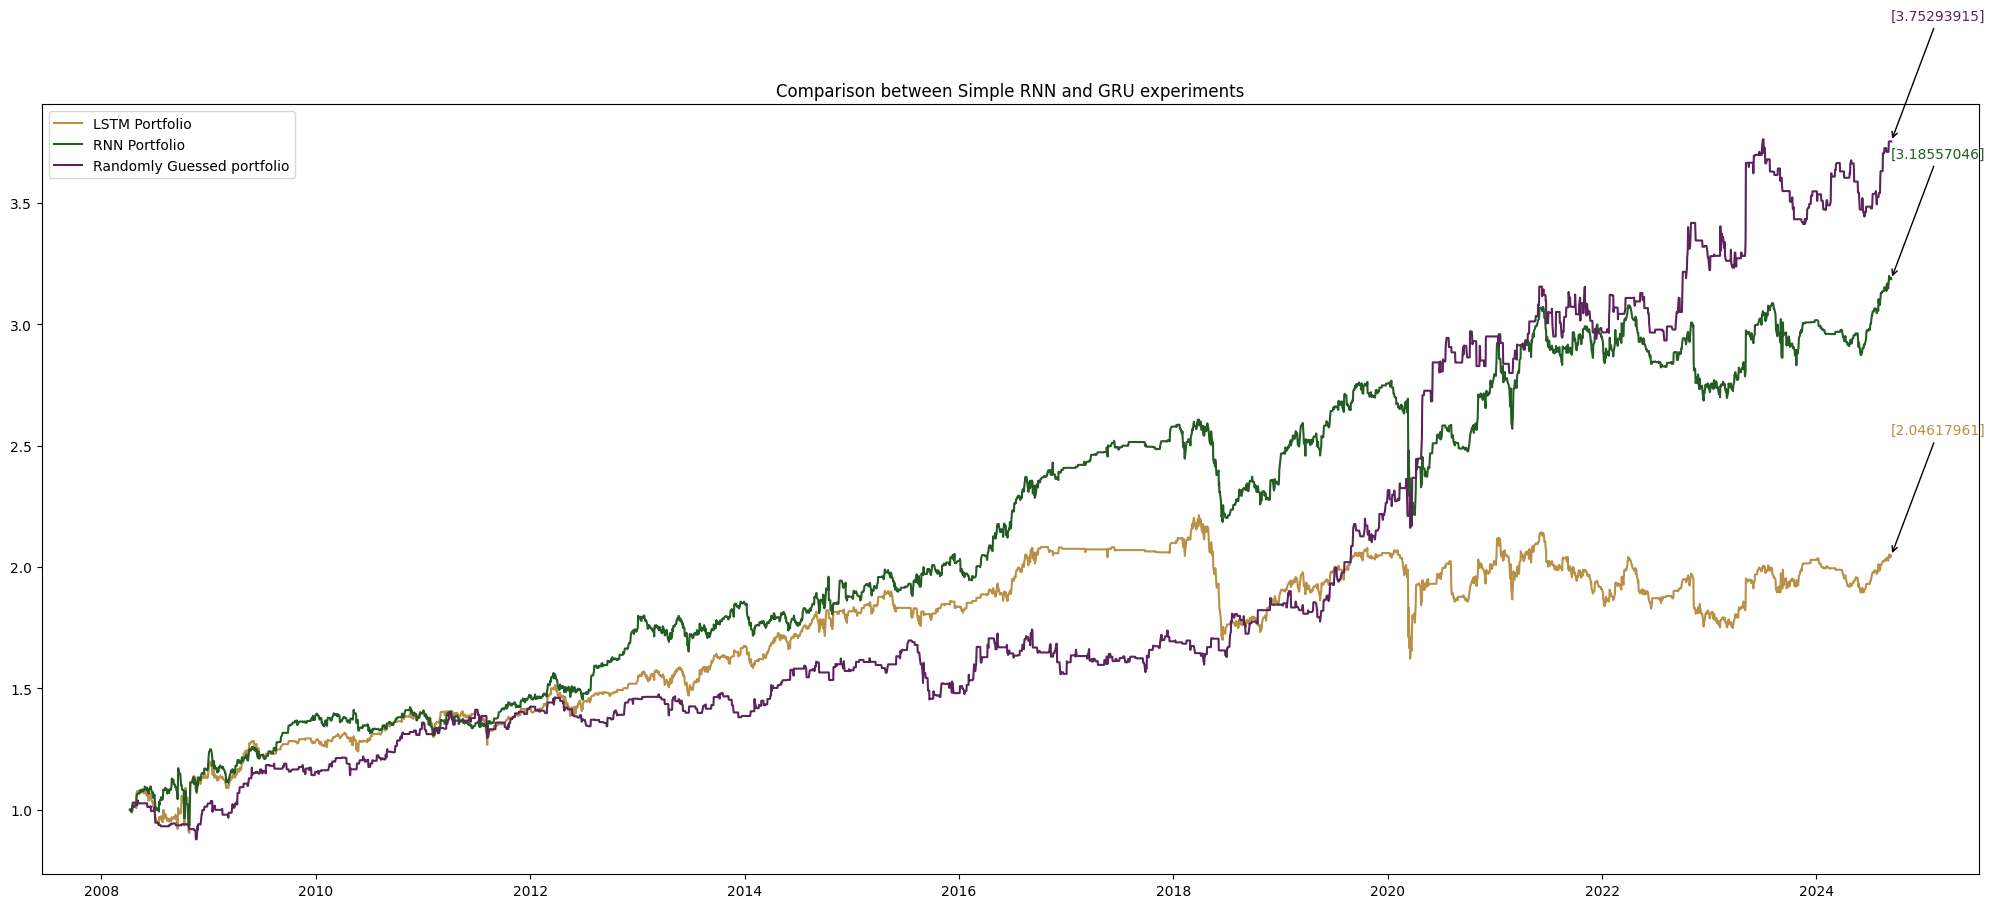

In [8]:
plot_many_returns_series(
    [cuml_perf_lstm_01, cuml_perf_rnn_1, cuml_perf_rg_1],
    ["LSTM Portfolio", "RNN Portfolio", "Randomly Guessed portfolio"], 
    daily_returns.index,
    [model_colors["GRU"], model_colors["RNN"], model_colors["RG"]],
    "Comparison between Simple RNN and GRU experiments",
)

O melhor portfólio aleatório supera o melhor portfólio da LSTM e da RNN simples, os dois modelos com o maior sharpe entre os modelos de ML

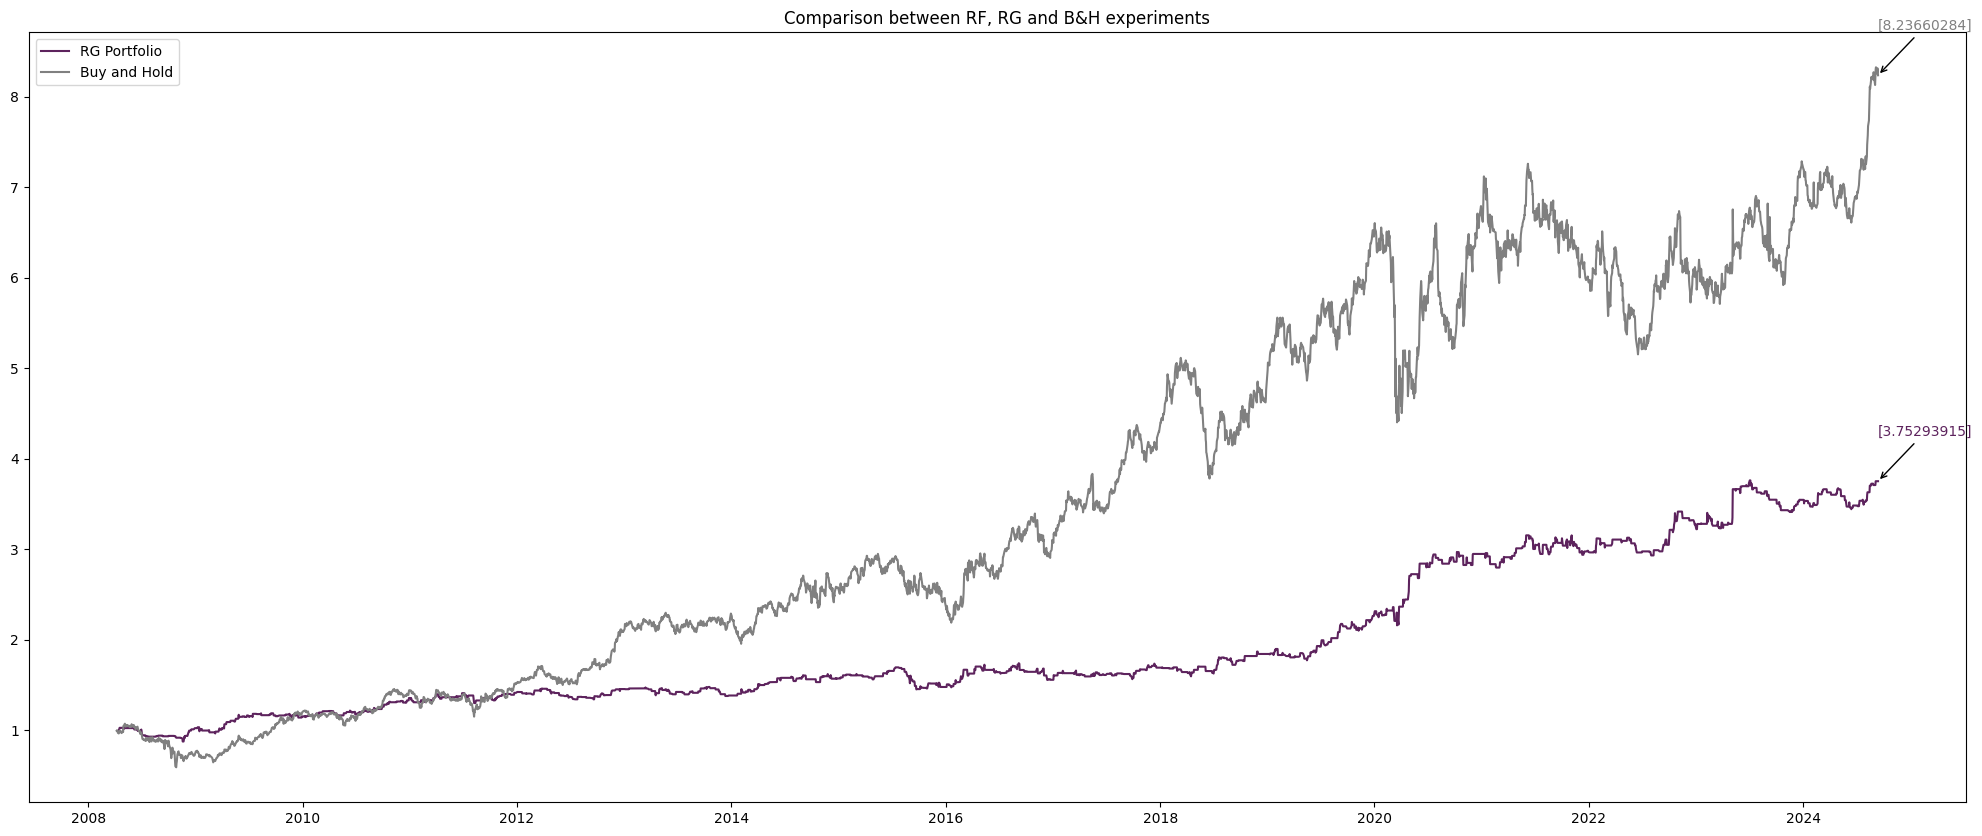

In [9]:
plot_many_returns_series(
    [cuml_perf_rg_1, buy_and_hold_cuml_returns],
    ["RG Portfolio", "Buy and Hold"], 
    daily_returns.index,
    [model_colors["RG"], model_colors["B&H"]],
    "Comparison between RF, RG and B&H experiments"
)

De toda forma, a estratégia Buy and Hold supera um portfólio aleatório (um bom sinal para o mercado)

### Distribuição das acurácias - INCLUIR

In [10]:
lstm_accs_1 = get_metric_distribution_from_results(results_lstm_1, "accuracy")
gru_accs_1 = get_metric_distribution_from_results(results_gru_1, "accuracy")
rnn_accs_1 = get_metric_distribution_from_results(results_rnn_1, "accuracy")
rf_accs_1 = get_metric_distribution_from_results(results_rf_1, "accuracy")
rg_accs_1 = get_metric_distribution_from_results(results_rg_1, "accuracy")

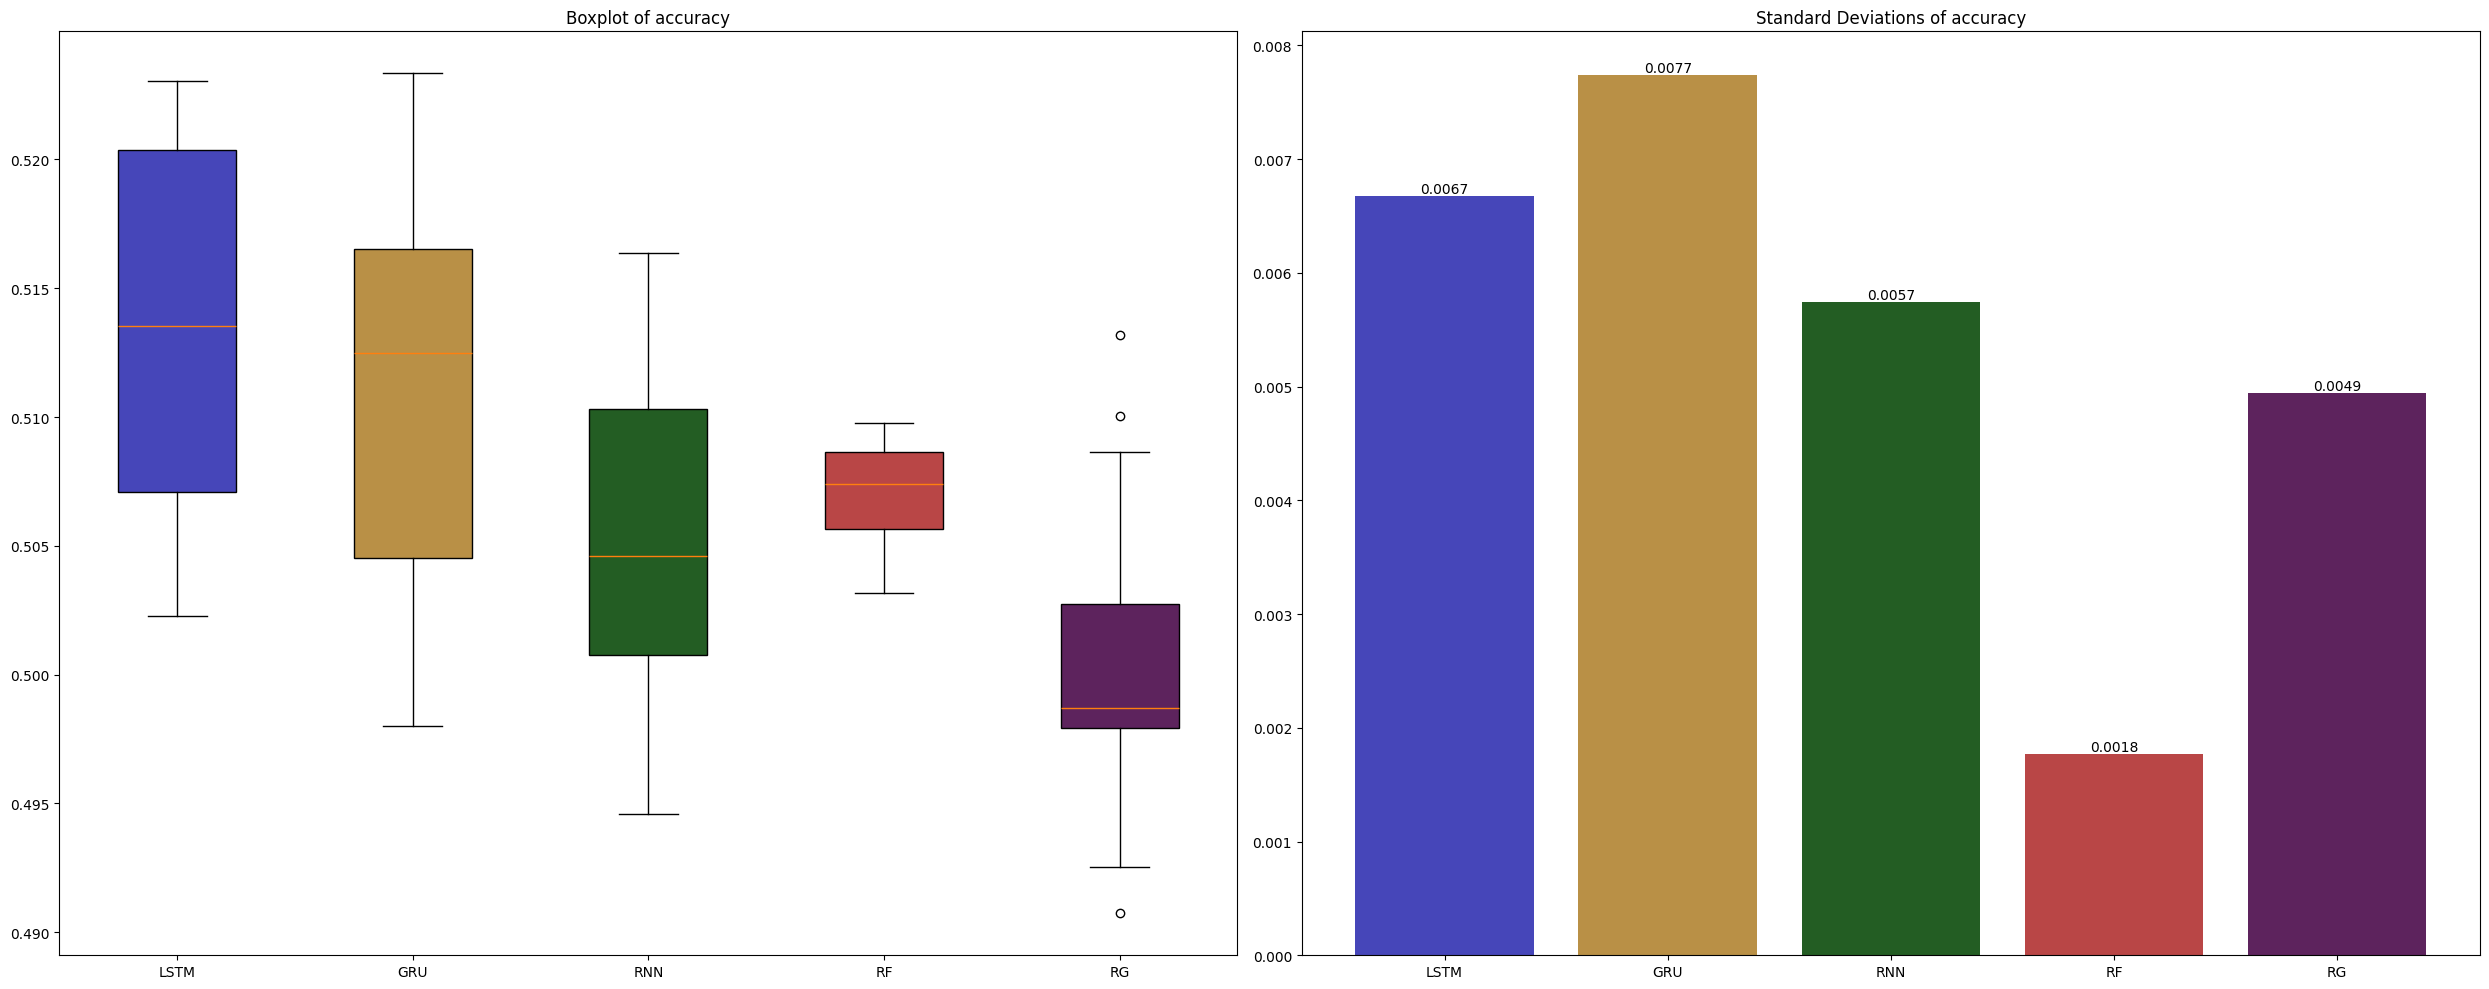

In [11]:
plot_distribution_and_stddev([
    lstm_accs_1,
    gru_accs_1,
    rnn_accs_1,
    rf_accs_1,
    rg_accs_1
], "accuracy")

In [12]:
print_statistics_table_for_series([
    lstm_accs_1,
    gru_accs_1,
    rnn_accs_1,
    rf_accs_1,
    rg_accs_1
])

+-------+--------------------+---------------------+--------------------+---------------------+-----------------------+----------------------+
| model |        mean        |        median       |        max         |         min         |         stddev        |      full range      |
+-------+--------------------+---------------------+--------------------+---------------------+-----------------------+----------------------+
|  LSTM | 0.5131862420659428 |  0.513537889200556  | 0.5230511793453194 |  0.5022580170196037 |  0.006675587139659745 | 0.02079316232571571  |
|  GRU  | 0.5113765793231695 |  0.5124834927262137 | 0.5233450443052942 |  0.497991507760975  |  0.007737562931431847 | 0.025353536544319155 |
|  RNN  | 0.5054570282392169 |  0.5046124552839035 | 0.5163821565302162 |  0.4946083256084866 |  0.005747598932460026 | 0.02177383092172963  |
|   RF  | 0.5071005761015496 |  0.507382092534081  | 0.5097593865609559 |  0.5031883187325108 | 0.0017741503823916218 | 0.006571067828445076 |

A distribuição das acurácias revolvem ao redor de 50%, indicando que as classificações não são muito melhores do que um chute aleatório. Isso significa que os modelos não conseguiram aprender nenhum padrão a partir dos dados

### Distribuição dos F1 Scores

In [13]:
lstm_f1_1 = get_metric_distribution_from_results(results_lstm_1, "f1")
gru_f1_1 = get_metric_distribution_from_results(results_gru_1, "f1")
rnn_f1_1 = get_metric_distribution_from_results(results_rnn_1, "f1")
rf_f1_1 = get_metric_distribution_from_results(results_rf_1, "f1")
rg_f1_1 = get_metric_distribution_from_results(results_rg_1, "f1")

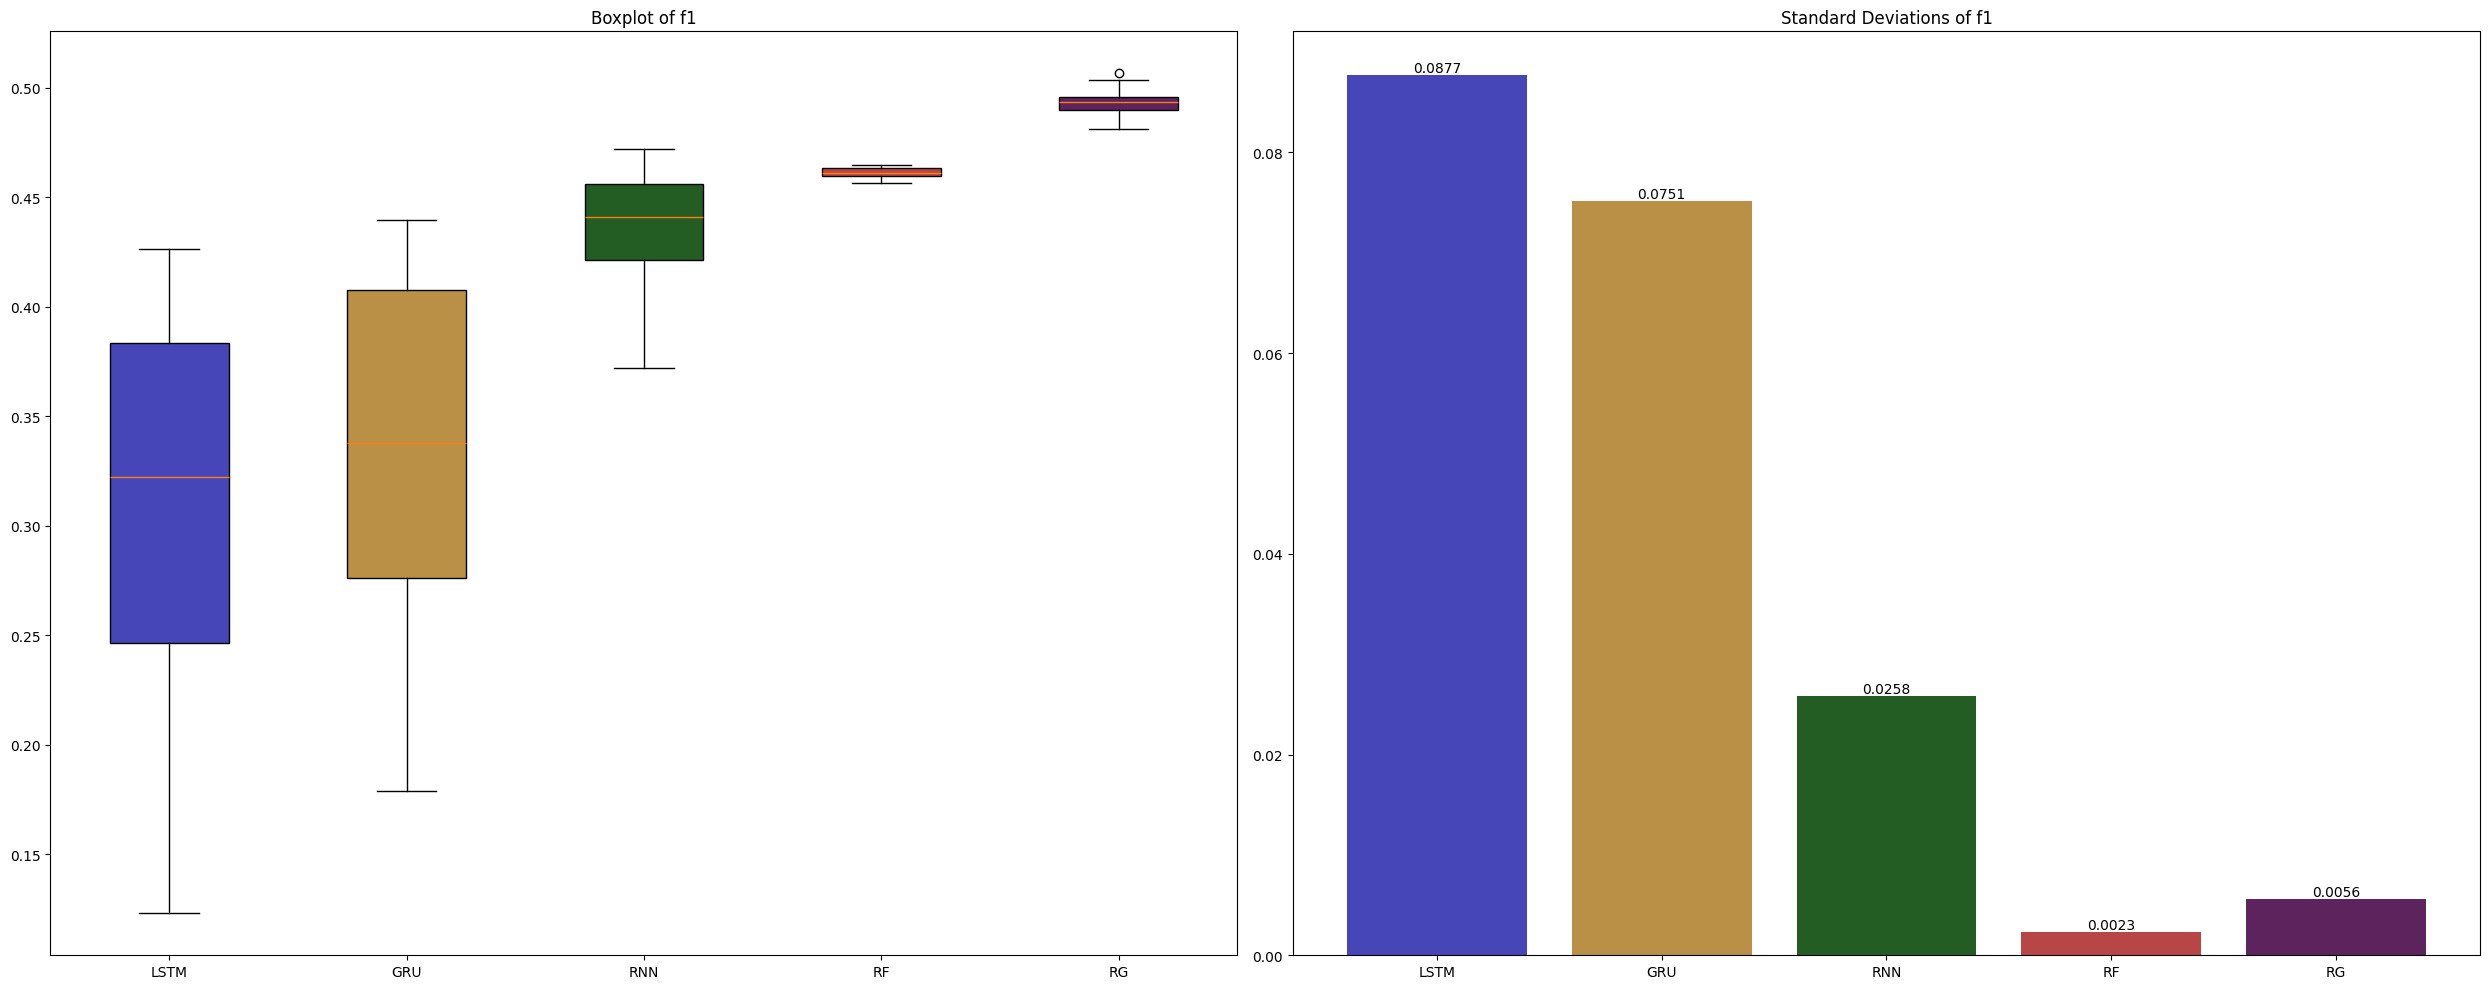

In [14]:
plot_distribution_and_stddev([
    lstm_f1_1,
    gru_f1_1,
    rnn_f1_1,
    rf_f1_1,
    rg_f1_1
], "f1")

In [15]:
print_statistics_table_for_series([
    lstm_f1_1,
    gru_f1_1,
    rnn_f1_1,
    rf_f1_1,
    rg_f1_1
])

+-------+---------------------+---------------------+---------------------+---------------------+----------------------+----------------------+
| model |         mean        |        median       |         max         |         min         |        stddev        |      full range      |
+-------+---------------------+---------------------+---------------------+---------------------+----------------------+----------------------+
|  LSTM | 0.30553630401725335 | 0.32245144450672003 |  0.4264118694956732 | 0.12309316322638511 | 0.08768904059676544  | 0.30331870626928814  |
|  GRU  | 0.33531956082605446 | 0.33761360361121595 |  0.4398276449233798 | 0.17911923897504223 | 0.07513501929635223  | 0.26070840594833755  |
|  RNN  | 0.43707014876723455 |  0.4412157997528253 |  0.4719689344716089 | 0.37216140800696806 | 0.025824052997181195 | 0.09980752646464086  |
|   RF  |  0.4612924613899288 | 0.46127793896984776 | 0.46479264444397705 | 0.45676374211427173 | 0.002284669859141479 | 0.0080289023297

### Análise de tempo de treinamento

In [16]:
lstm_time_1 = get_metric_distribution_from_results(results_lstm_1, "dataset_fit_predict_time")
gru_time_1 = get_metric_distribution_from_results(results_gru_1, "dataset_fit_predict_time")
rnn_time_1 = get_metric_distribution_from_results(results_rnn_1, "dataset_fit_predict_time")
rf_time_1 = get_metric_distribution_from_results(results_rf_1, "dataset_fit_predict_time")

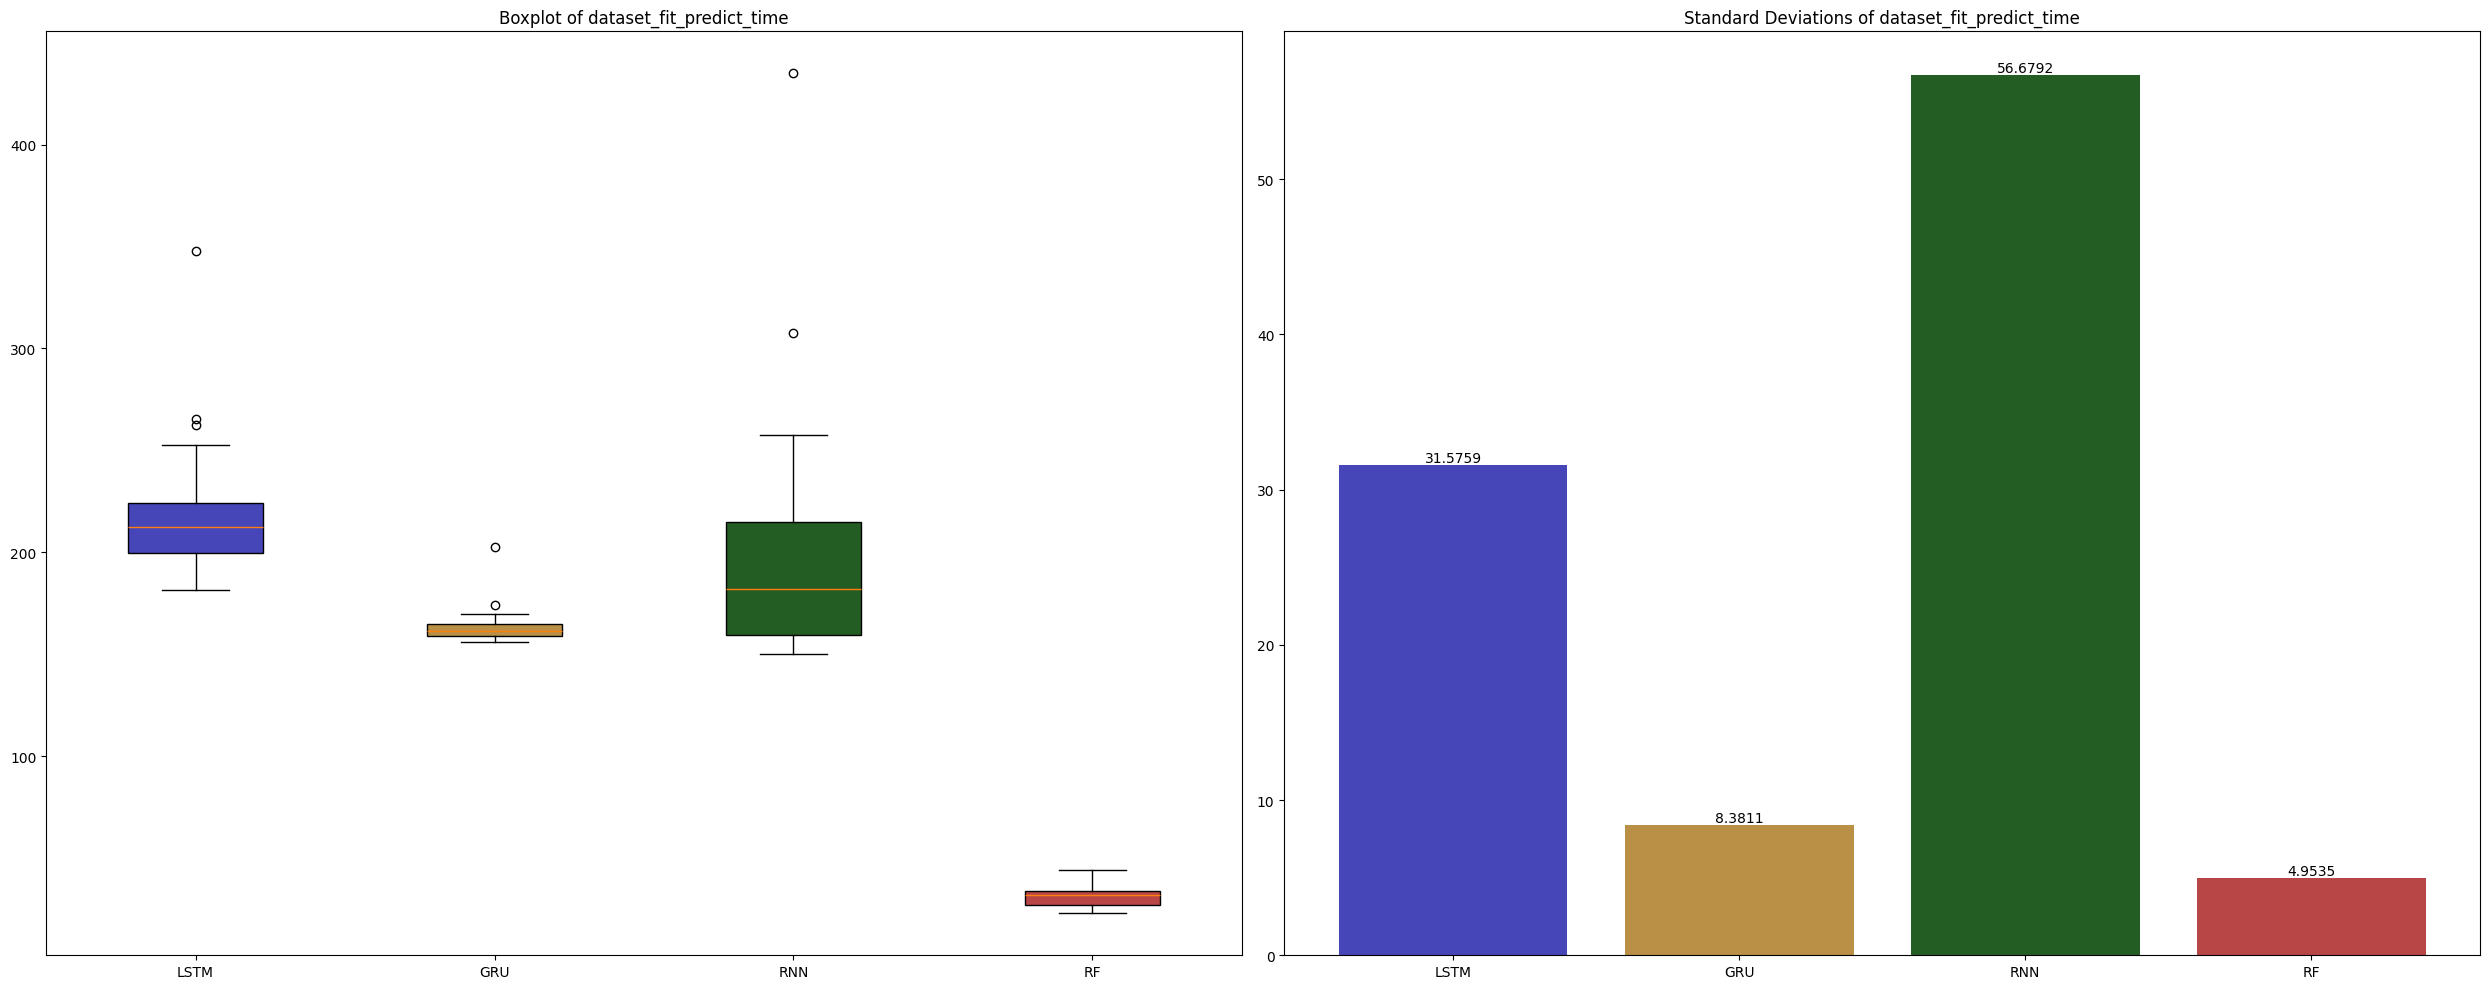

In [17]:
plot_distribution_and_stddev([
    lstm_time_1,
    gru_time_1,
    rnn_time_1,
    rf_time_1
], "dataset_fit_predict_time")

### Correlação entre Sharpes e acurácias; Sharpes e F1; Acc e F1 - TALVEZ INCLUIR POR CAUSA DA CORR DO F1 COM SHARPE

In [18]:
sharpes_accs_pairs = [
    (lstm_sharpes_1, lstm_accs_1),
    (gru_sharpes_1, gru_accs_1),
    (rnn_sharpes_1, rnn_accs_1),
    (rf_sharpes_1, rf_accs_1)
]

sharpes_f1s_pairs = [
    (lstm_sharpes_1, lstm_f1_1),
    (gru_sharpes_1, gru_f1_1),
    (rnn_sharpes_1, rnn_f1_1),
    (rf_sharpes_1, rf_f1_1)
]

accs_f1s_pairs = [
    (lstm_accs_1, lstm_f1_1),
    (gru_accs_1, gru_f1_1),
    (rnn_accs_1, rnn_f1_1),
    (rf_accs_1, rf_f1_1)
]

model_list = ["LSTM", "GRU", "RNN", "RF"]

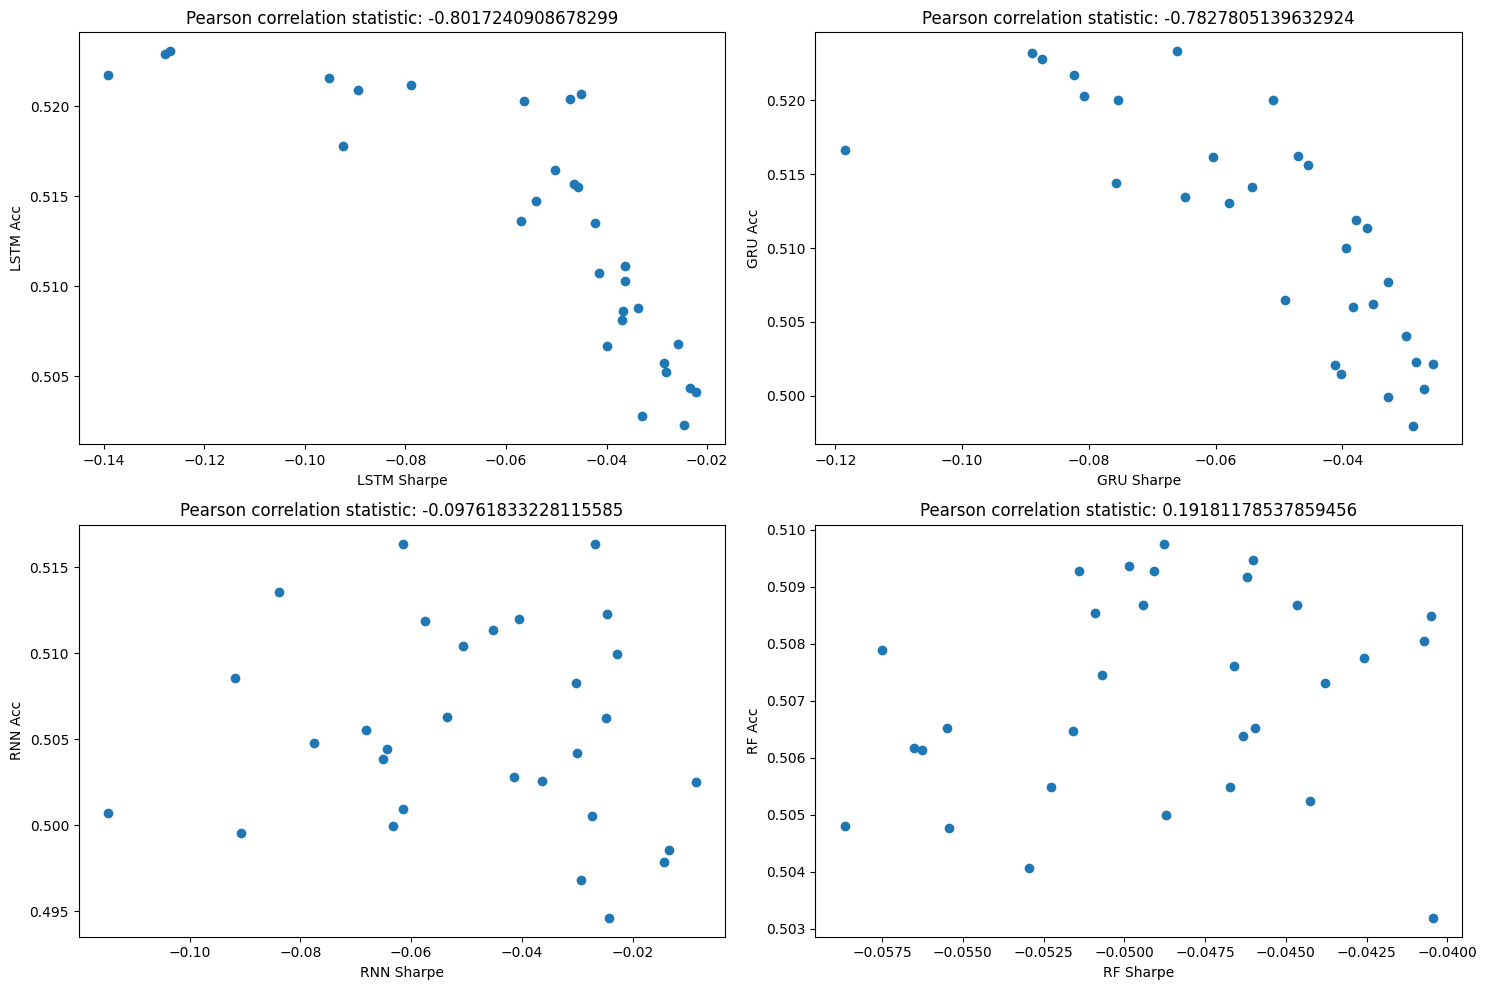

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes = axes.flatten()

for i, ax in enumerate(axes):
    x, y = sharpes_accs_pairs[i]
    ax.scatter(x, y)
    ax.set_title(f"Pearson correlation statistic: {pearsonr(x, y).statistic}")
    ax.set_xlabel(f"{model_list[i]} Sharpe")
    ax.set_ylabel(f"{model_list[i]} Acc")

plt.tight_layout()
plt.show()

Curioso identificar que um sharpe melhor não tem correlação positiva e/ou significativa com uma acurácia melhor. Isso não diz muito sobre a capacidade dos modelos de aprender padrões e criar um portfólio melhor com base em métricas melhores. Isso pode dizer mais sobre a relação com a precisão e o recall versus acurácia e versus sharpe

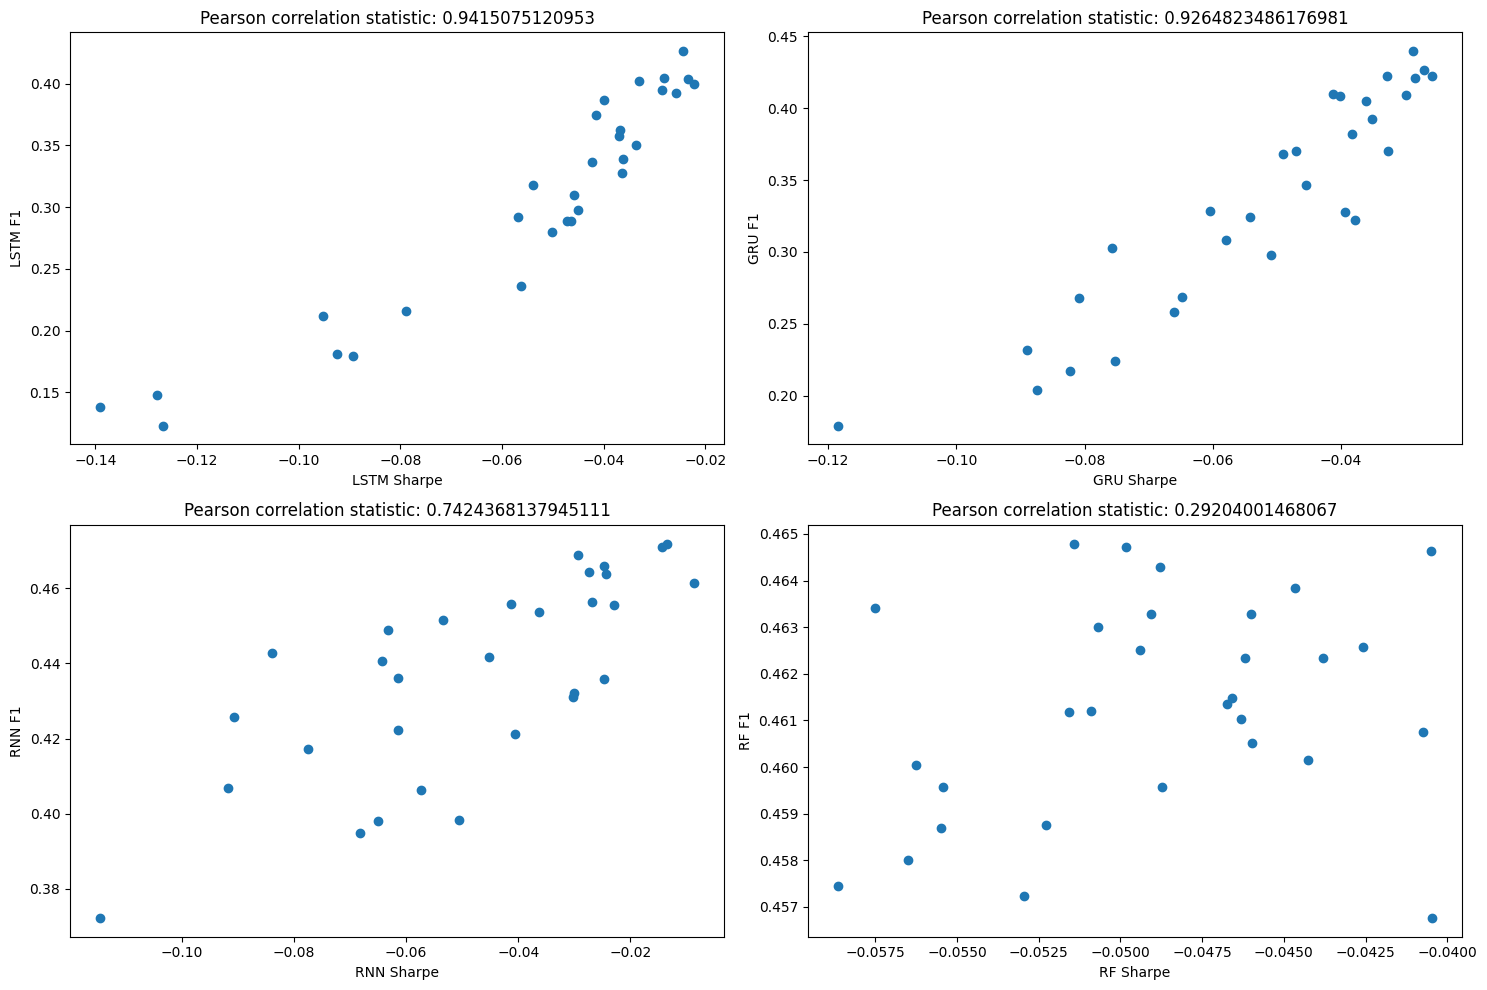

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes = axes.flatten()

for i, ax in enumerate(axes):
    x, y = sharpes_f1s_pairs[i]
    ax.scatter(x, y)
    ax.set_title(f"Pearson correlation statistic: {pearsonr(x, y).statistic}")
    ax.set_xlabel(f"{model_list[i]} Sharpe")
    ax.set_ylabel(f"{model_list[i]} F1")

plt.tight_layout()
plt.show()

Um F1 melhor, por outro lado, é correlacionado com um sharpe maior em 3 dos 4 modelos. O F1 sendo uma média harmônica entre precisão e recall, imagina-se que um melhor equilíbrio entre precisão e recall, em que um não cai em detrimento do outro, leva a decisões melhores, ainda que não boas o suficiente

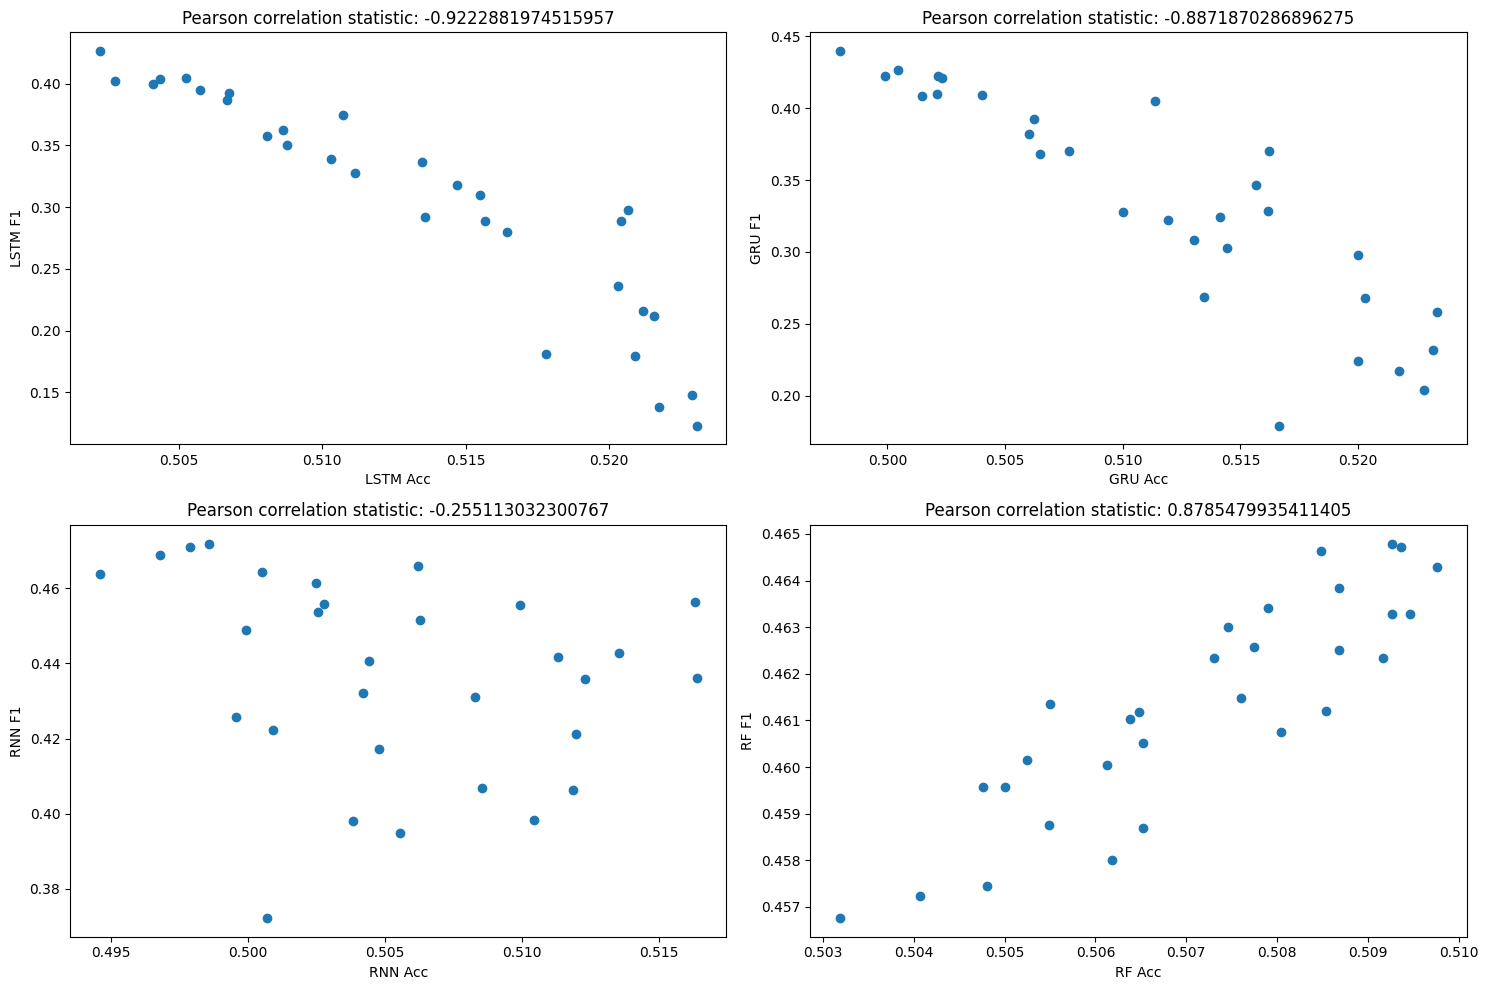

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes = axes.flatten()

for i, ax in enumerate(axes):
    x, y = accs_f1s_pairs[i]
    ax.scatter(x, y)
    ax.set_title(f"Pearson correlation statistic: {pearsonr(x, y).statistic}")
    ax.set_xlabel(f"{model_list[i]} Acc")
    ax.set_ylabel(f"{model_list[i]} F1")

plt.tight_layout()
plt.show()

Um F1 melhor leva a uma acurácia pior na LSTM e na GRU. Talvez a acurácia levemente maior se deva a um caso ingênuo em que o modelo prioriza uma das classes, no total conseguindo uma acurácia maior mas em detrimento do recall, o que leva o F1 pra baixo. Por exemplo, se o modelo prioriza a classe 0, entre os preditos ele vai acertar vários 0 (precisão), mas vai deixar de capturar várias instâncias positivas reais (recall)

## precisão x recall x acurácia na LSTM e GRU

In [22]:
lstm_precision_1 = get_metric_distribution_from_results(results_lstm_1, "precision")
gru_precision_1 = get_metric_distribution_from_results(results_gru_1, "precision")

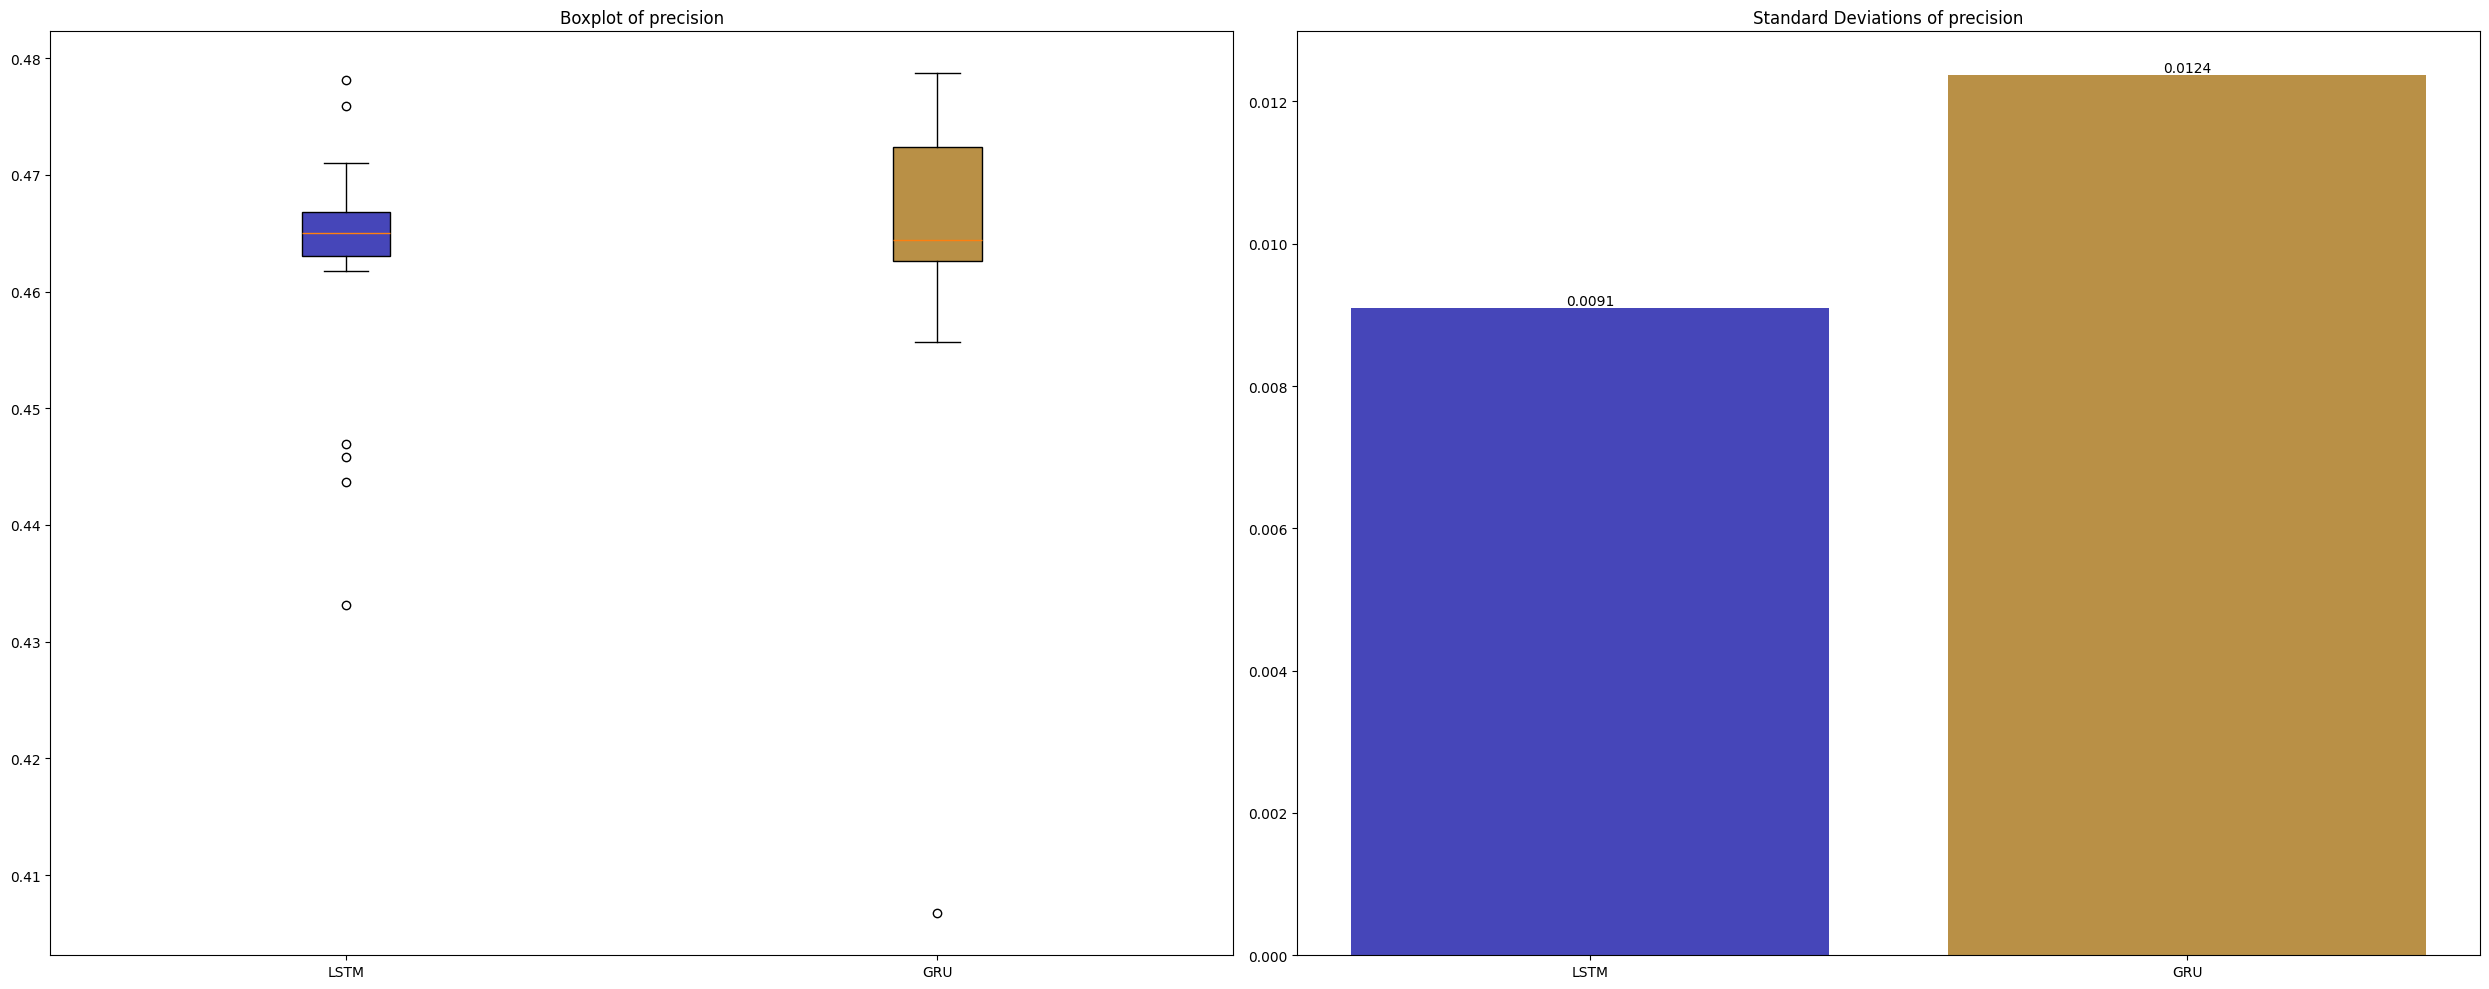

In [23]:
plot_distribution_and_stddev([
    lstm_precision_1,
    gru_precision_1,
], "precision")

In [24]:
lstm_recall_1 = get_metric_distribution_from_results(results_lstm_1, "recall")
gru_recall_1 = get_metric_distribution_from_results(results_gru_1, "recall")

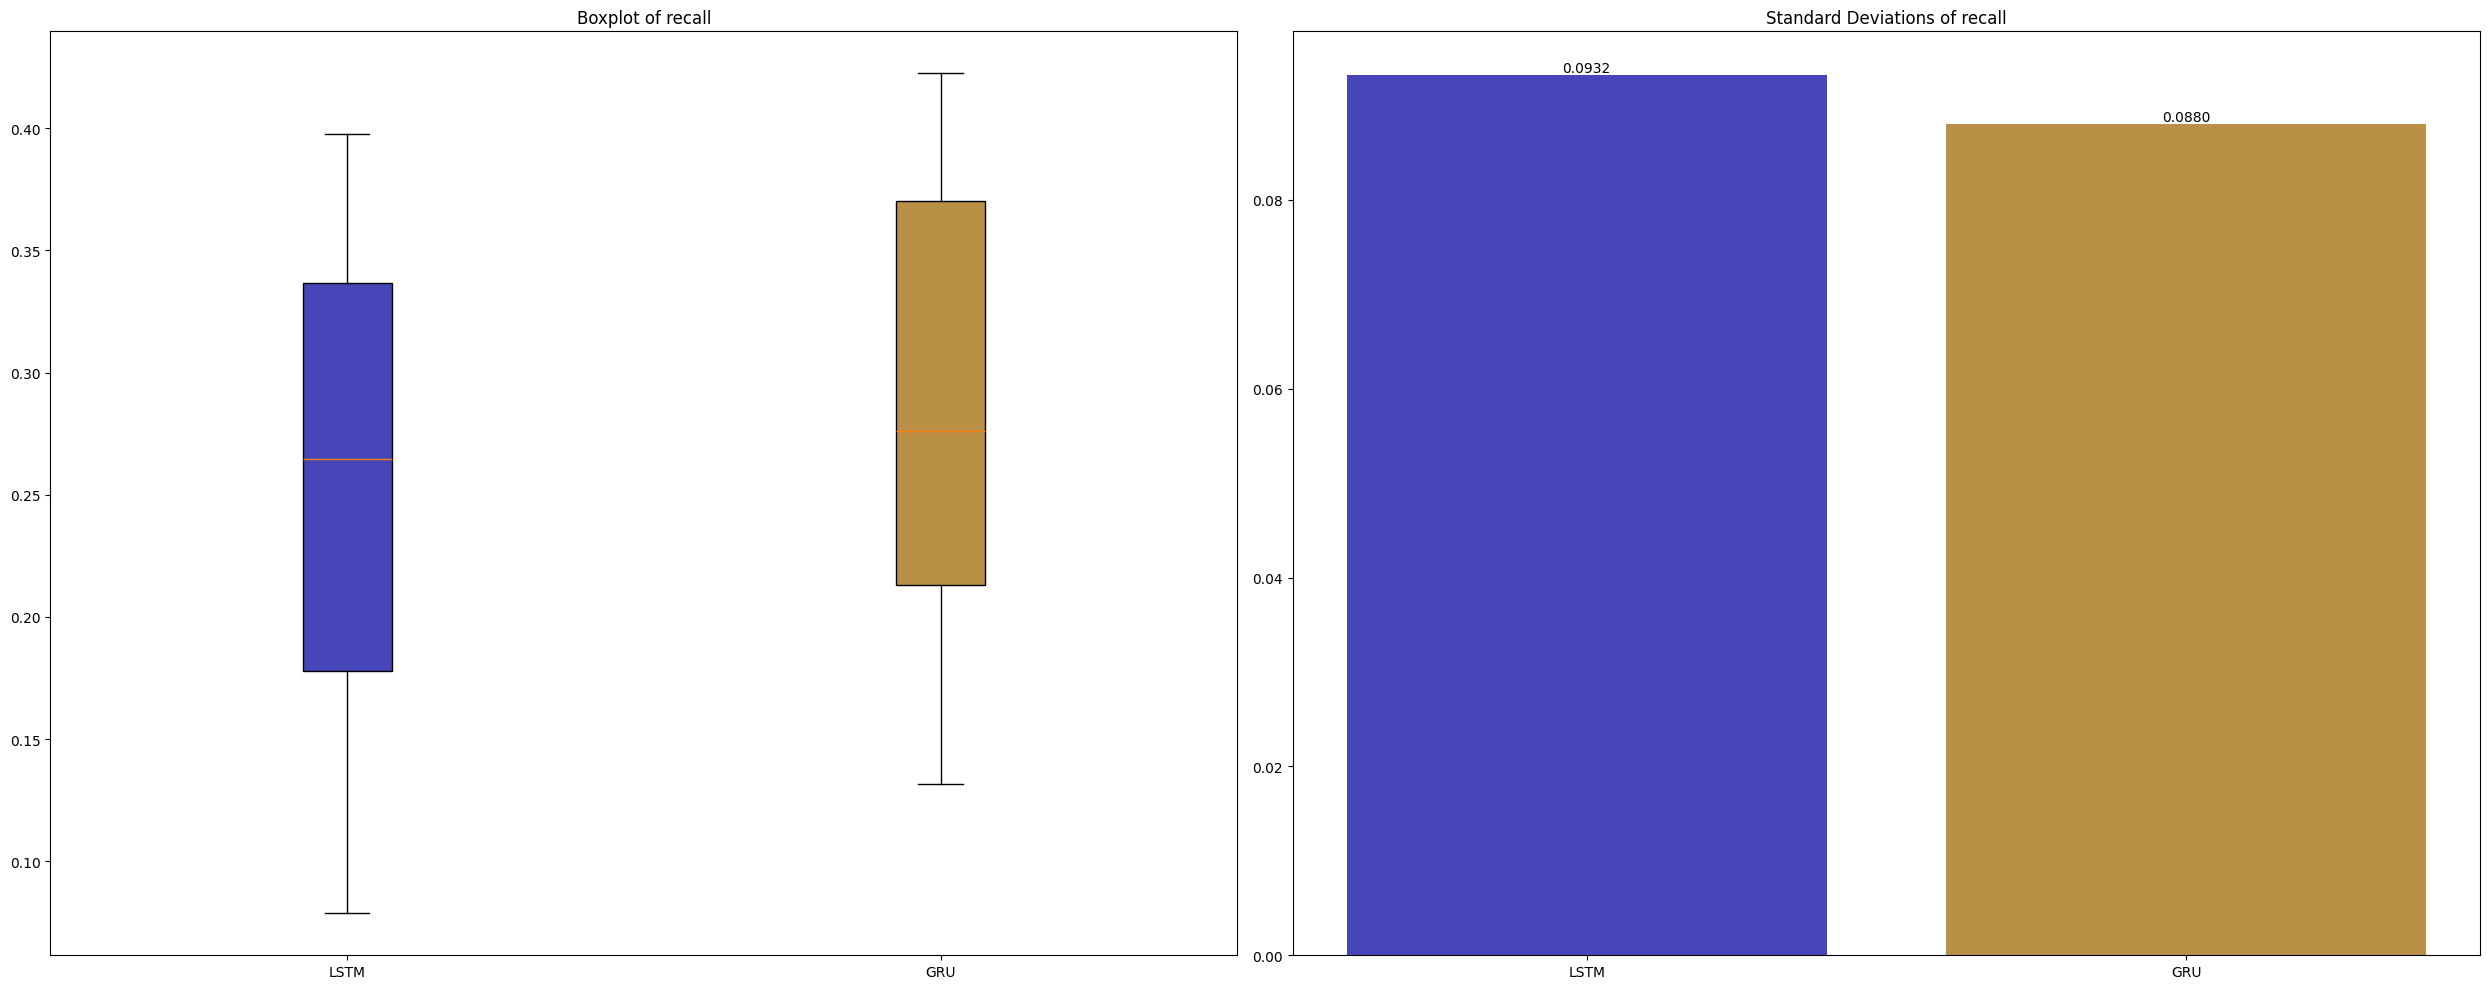

In [25]:
plot_distribution_and_stddev([
    lstm_recall_1,
    gru_recall_1,
], "recall")

In [26]:
precision_accs_pairs = [
    (lstm_precision_1, lstm_accs_1),
    (gru_precision_1, gru_accs_1)
]

recall_accs_pairs = [
    (lstm_recall_1, lstm_accs_1),
    (gru_recall_1, gru_accs_1)
]

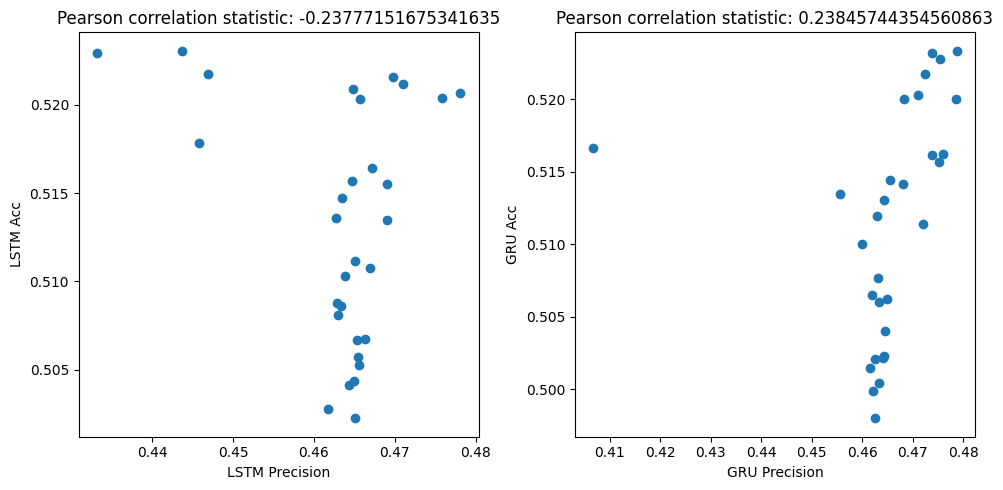

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes = axes.flatten()

for i, ax in enumerate(axes):
    x, y = precision_accs_pairs[i]
    ax.scatter(x, y)
    ax.set_title(f"Pearson correlation statistic: {pearsonr(x, y).statistic}")
    ax.set_xlabel(f"{model_list[i]} Precision")
    ax.set_ylabel(f"{model_list[i]} Acc")

plt.tight_layout()
plt.show()

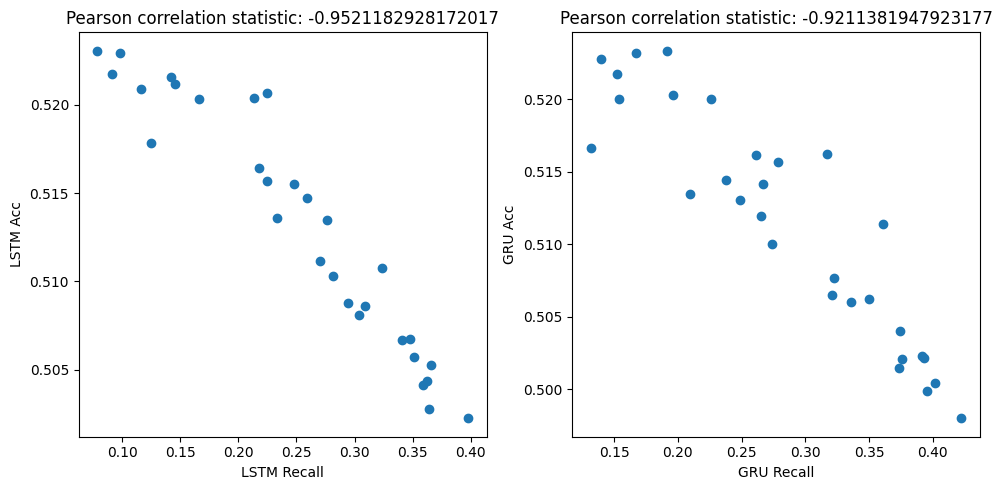

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes = axes.flatten()

for i, ax in enumerate(axes):
    x, y = recall_accs_pairs[i]
    ax.scatter(x, y)
    ax.set_title(f"Pearson correlation statistic: {pearsonr(x, y).statistic}")
    ax.set_xlabel(f"{model_list[i]} Recall")
    ax.set_ylabel(f"{model_list[i]} Acc")

plt.tight_layout()
plt.show()

Confirmando a suposição de que uma acurácia maior acarreta em um recall menor para esses dois modelos

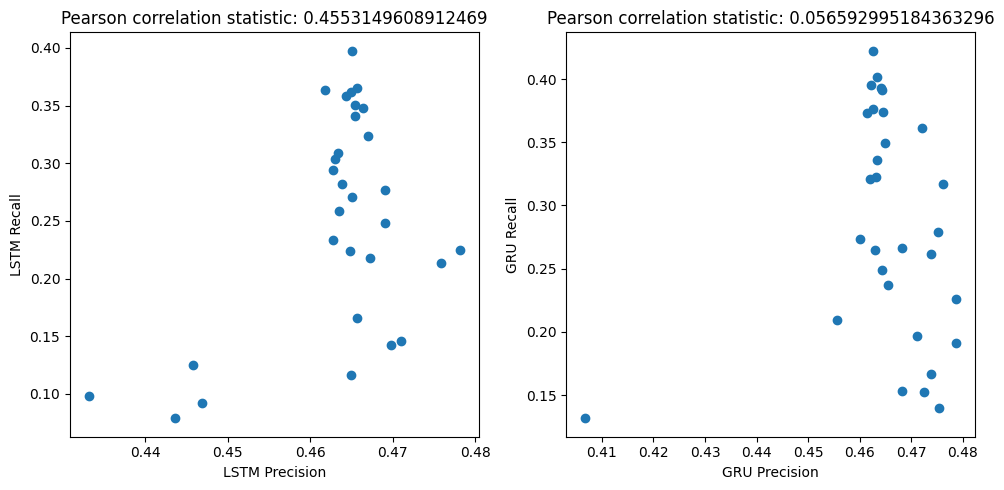

In [29]:
precision_recall_pairs = [
    (lstm_precision_1, lstm_recall_1),
    (gru_precision_1, gru_recall_1)
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes = axes.flatten()

for i, ax in enumerate(axes):
    x, y = precision_recall_pairs[i]
    ax.scatter(x, y)
    ax.set_title(f"Pearson correlation statistic: {pearsonr(x, y).statistic}")
    ax.set_xlabel(f"{model_list[i]} Precision")
    ax.set_ylabel(f"{model_list[i]} Recall")

plt.tight_layout()
plt.show()

## precisão / recall x sharpe

In [30]:
rnn_recall_1 = get_metric_distribution_from_results(results_rnn_1, "recall")
rf_recall_1 = get_metric_distribution_from_results(results_rf_1, "recall")

rnn_precision_1 = get_metric_distribution_from_results(results_rnn_1, "precision")
rf_precision_1 = get_metric_distribution_from_results(results_rf_1, "precision")

In [31]:
sharpes_precision_pairs = [
    (lstm_sharpes_1, lstm_precision_1),
    (gru_sharpes_1, gru_precision_1),
    (rnn_sharpes_1, rnn_precision_1),
    (rf_sharpes_1, rf_precision_1)
]

sharpes_recalls_pairs = [
    (lstm_sharpes_1, lstm_recall_1),
    (gru_sharpes_1, gru_recall_1),
    (rnn_sharpes_1, rnn_recall_1),
    (rf_sharpes_1, rf_recall_1)
]


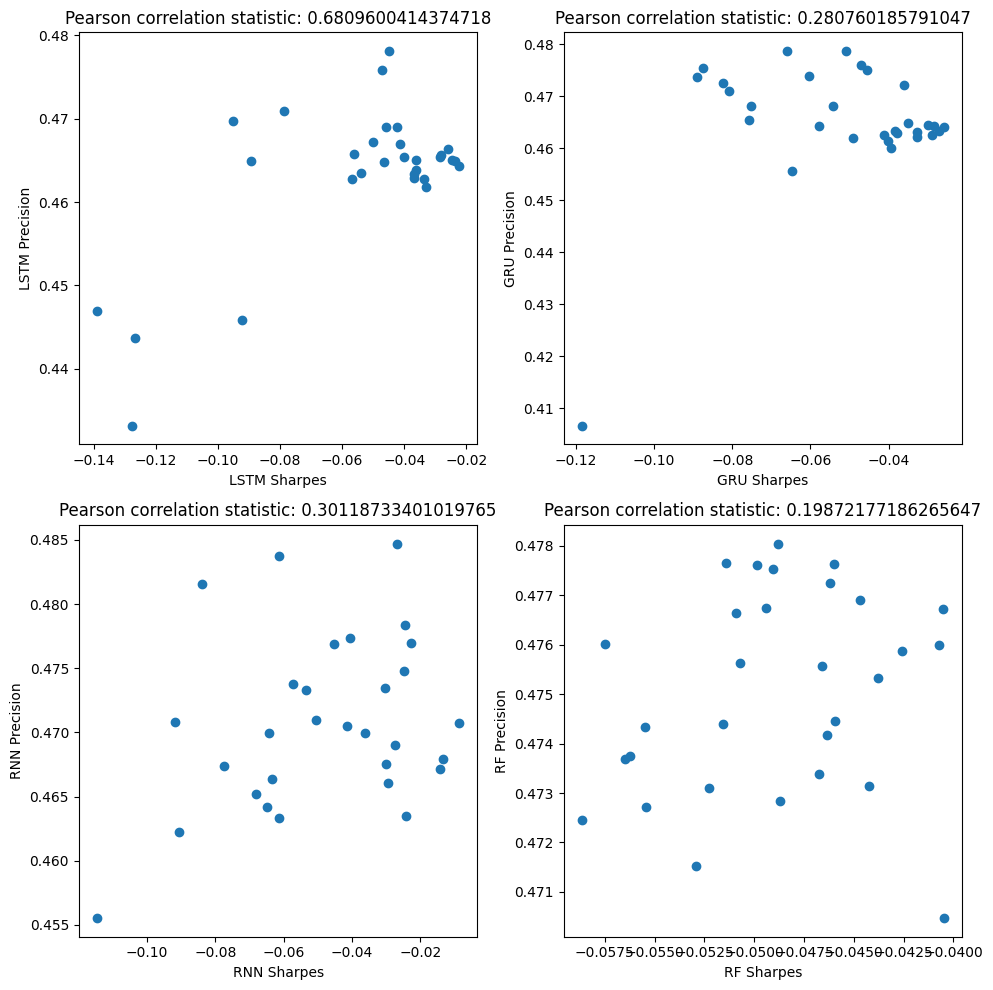

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes = axes.flatten()

for i, ax in enumerate(axes):
    x, y = sharpes_precision_pairs[i]
    ax.scatter(x, y)
    ax.set_title(f"Pearson correlation statistic: {pearsonr(x, y).statistic}")
    ax.set_xlabel(f"{model_list[i]} Sharpes")
    ax.set_ylabel(f"{model_list[i]} Precision")

plt.tight_layout()
plt.show()

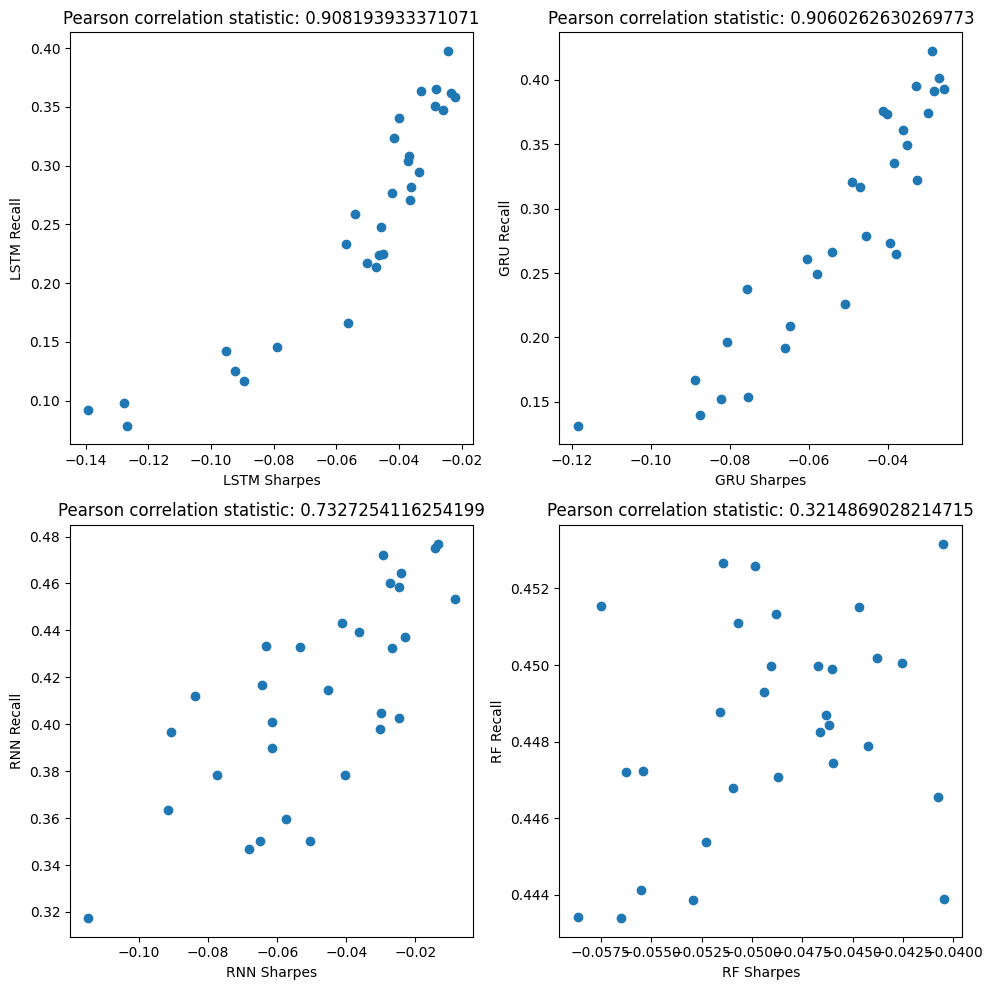

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes = axes.flatten()

for i, ax in enumerate(axes):
    x, y = sharpes_recalls_pairs[i]
    ax.scatter(x, y)
    ax.set_title(f"Pearson correlation statistic: {pearsonr(x, y).statistic}")
    ax.set_xlabel(f"{model_list[i]} Sharpes")
    ax.set_ylabel(f"{model_list[i]} Recall")

plt.tight_layout()
plt.show()

3 das 4 vezes um recall melhor levou a um sharpe melhor. Faz sentido considerando que nesse problema é melhor capturar as instâncias reais, e falsos positivos são mais danosos pois acarretam em perda de dinheiro, enquanto o falso negativo apenas deixa de ganhar

## Comitê dos top 3 modelos

Será avaliado se um comitê dos top 3 modelos treinados toma decisões melhores do que seus constituintes individuais na formação de uma carteira

In [34]:
stocks = ["abev3", "bbdc3", "itsa3", "itub3", "wege3"]

Tirando o voto majoritário das previsões dos modelos...

In [35]:
len(results_lstm_1)
all_preds_lstm = {}
all_preds_gru = {}
all_preds_rnn = {}
for stock in stocks:
    all_preds_lstm[stock] = [result[stock][1] for result in results_lstm_1]
    all_preds_gru[stock] = [result[stock][1] for result in results_gru_1]
    all_preds_rnn[stock] = [result[stock][1] for result in results_rnn_1]

print(len(all_preds_lstm["abev3"]))
print(len(list(all_preds_lstm["abev3"][0])))

all_preds_ensemble = {}
for stock in stocks:
    all_preds_ensemble[stock] = [[] for _ in range(len(all_preds_lstm["abev3"]))]

res_ensemble = []

for experiment in range(len(results_lstm_1)):
    partial_res = {}
    for stock in stocks:
        lstm = all_preds_lstm[stock][experiment]

        gru = all_preds_gru[stock][experiment]

        rnn = all_preds_rnn[stock][experiment]

        ensemble = [0 for _ in range(len(lstm))]
        
        for i in range(len(lstm)):
            triplet = [lstm[i], gru[i], rnn[i]]
            values = [list(item.values())[0] for item in triplet]
            if values.count(1) > values.count(0):
                ensemble[i] = {list(triplet[0].keys())[0]: 1}
            else:
                ensemble[i] = {list(triplet[0].keys())[0]: 0}

        preds_to_compute = [list(item.values())[0] for item in ensemble]
        grounds_to_compute = results_lstm_1[0][stock][0]["ground"]
        metrics = {
            "accuracy": accuracy_score(grounds_to_compute, preds_to_compute),
            "f1": f1_score(grounds_to_compute, preds_to_compute),
            "precision": precision_score(grounds_to_compute, preds_to_compute, zero_division=0),
            "recall": recall_score(grounds_to_compute, preds_to_compute),
        }
        partial_res[stock] = (metrics, ensemble)
    res_ensemble.append(partial_res)

30
4079


In [36]:
len(res_ensemble[0]["abev3"][1])

4079

In [37]:
best_results_ensemble, cuml_perf_ensemble, max_sharpe_ensemble, best_exp_idx_ensemble = find_best_experiment(res_ensemble, daily_returns)

Selected exp number 25


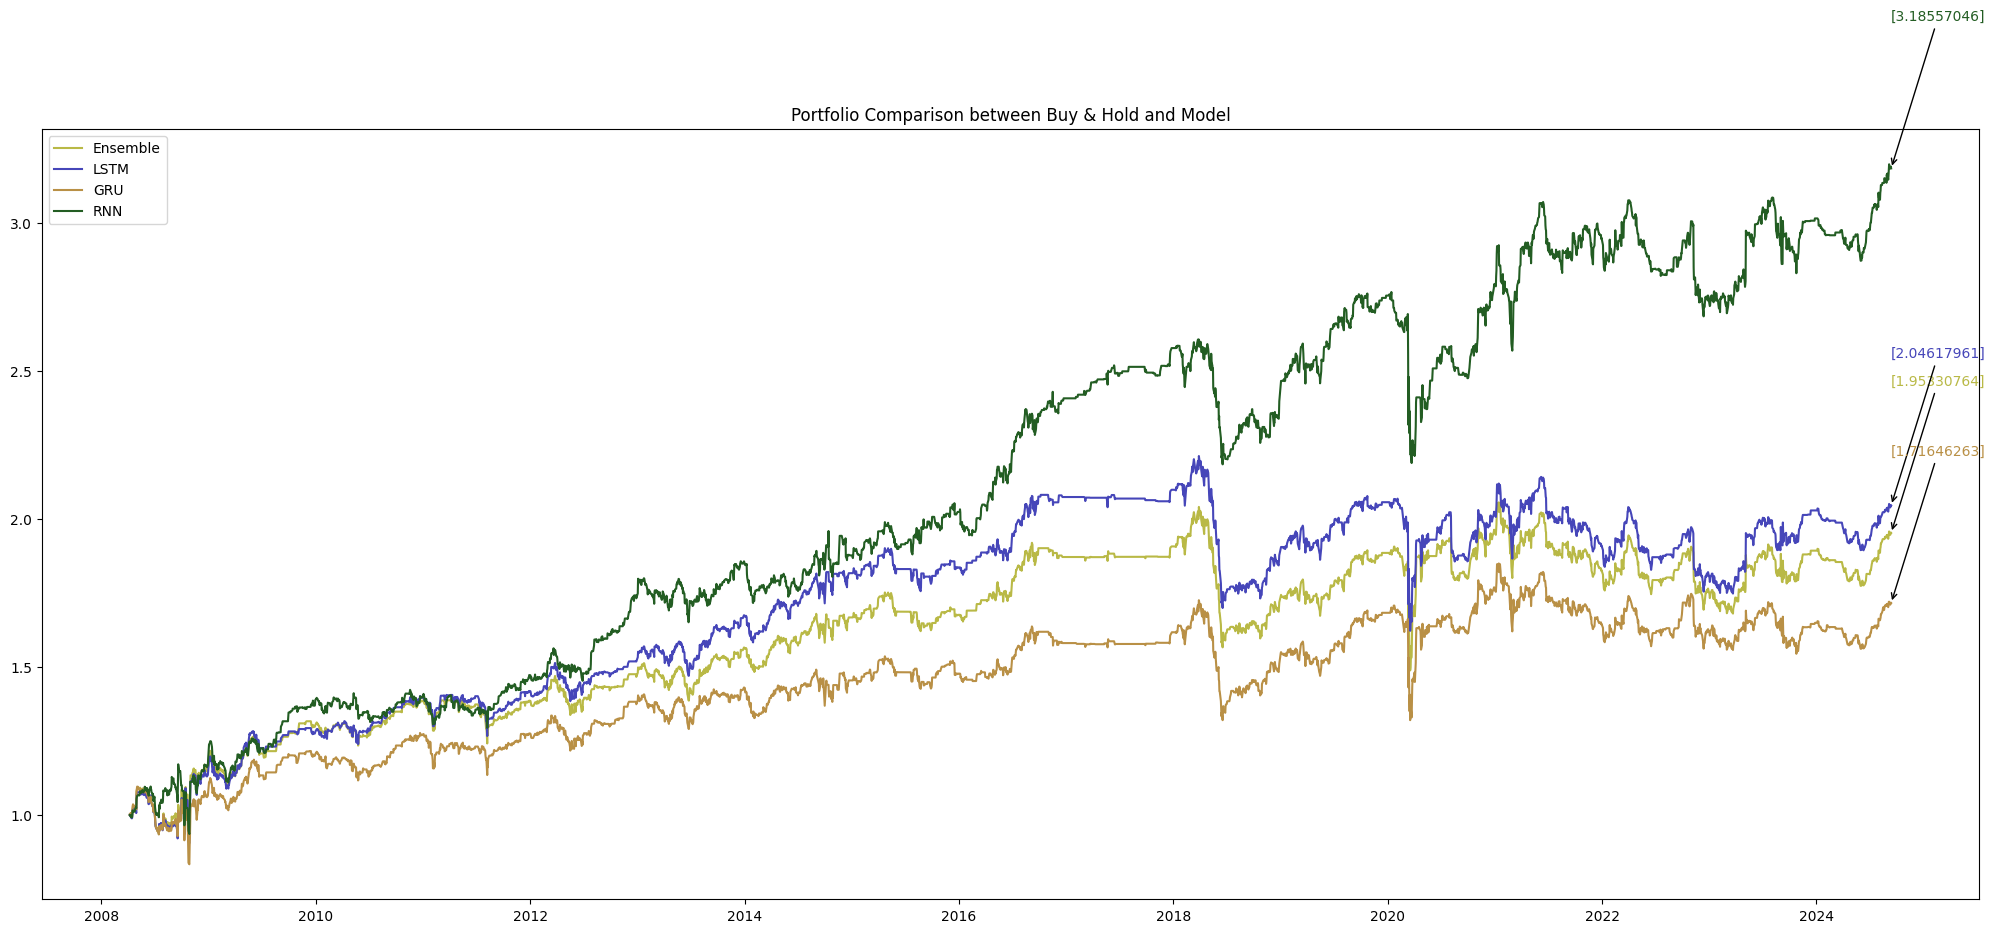

In [38]:
plot_many_returns_series(
    [cuml_perf_ensemble, cuml_perf_lstm_01, cuml_perf_gru_1, cuml_perf_rnn_1], 
    ["Ensemble", "LSTM", "GRU", "RNN"], 
    daily_returns.index, 
    colors=[model_colors["Ensemble"], model_colors["LSTM"], model_colors["GRU"], model_colors["RNN"]]
)

O comitê só é melhor que a GRU, mas perde por pouco para a LSTM e a RNN simples

In [39]:
ensemble_sharpes = get_sharpe_series_from_results(res_ensemble, daily_returns)
ensemble_accs = get_metric_distribution_from_results(res_ensemble, "accuracy")

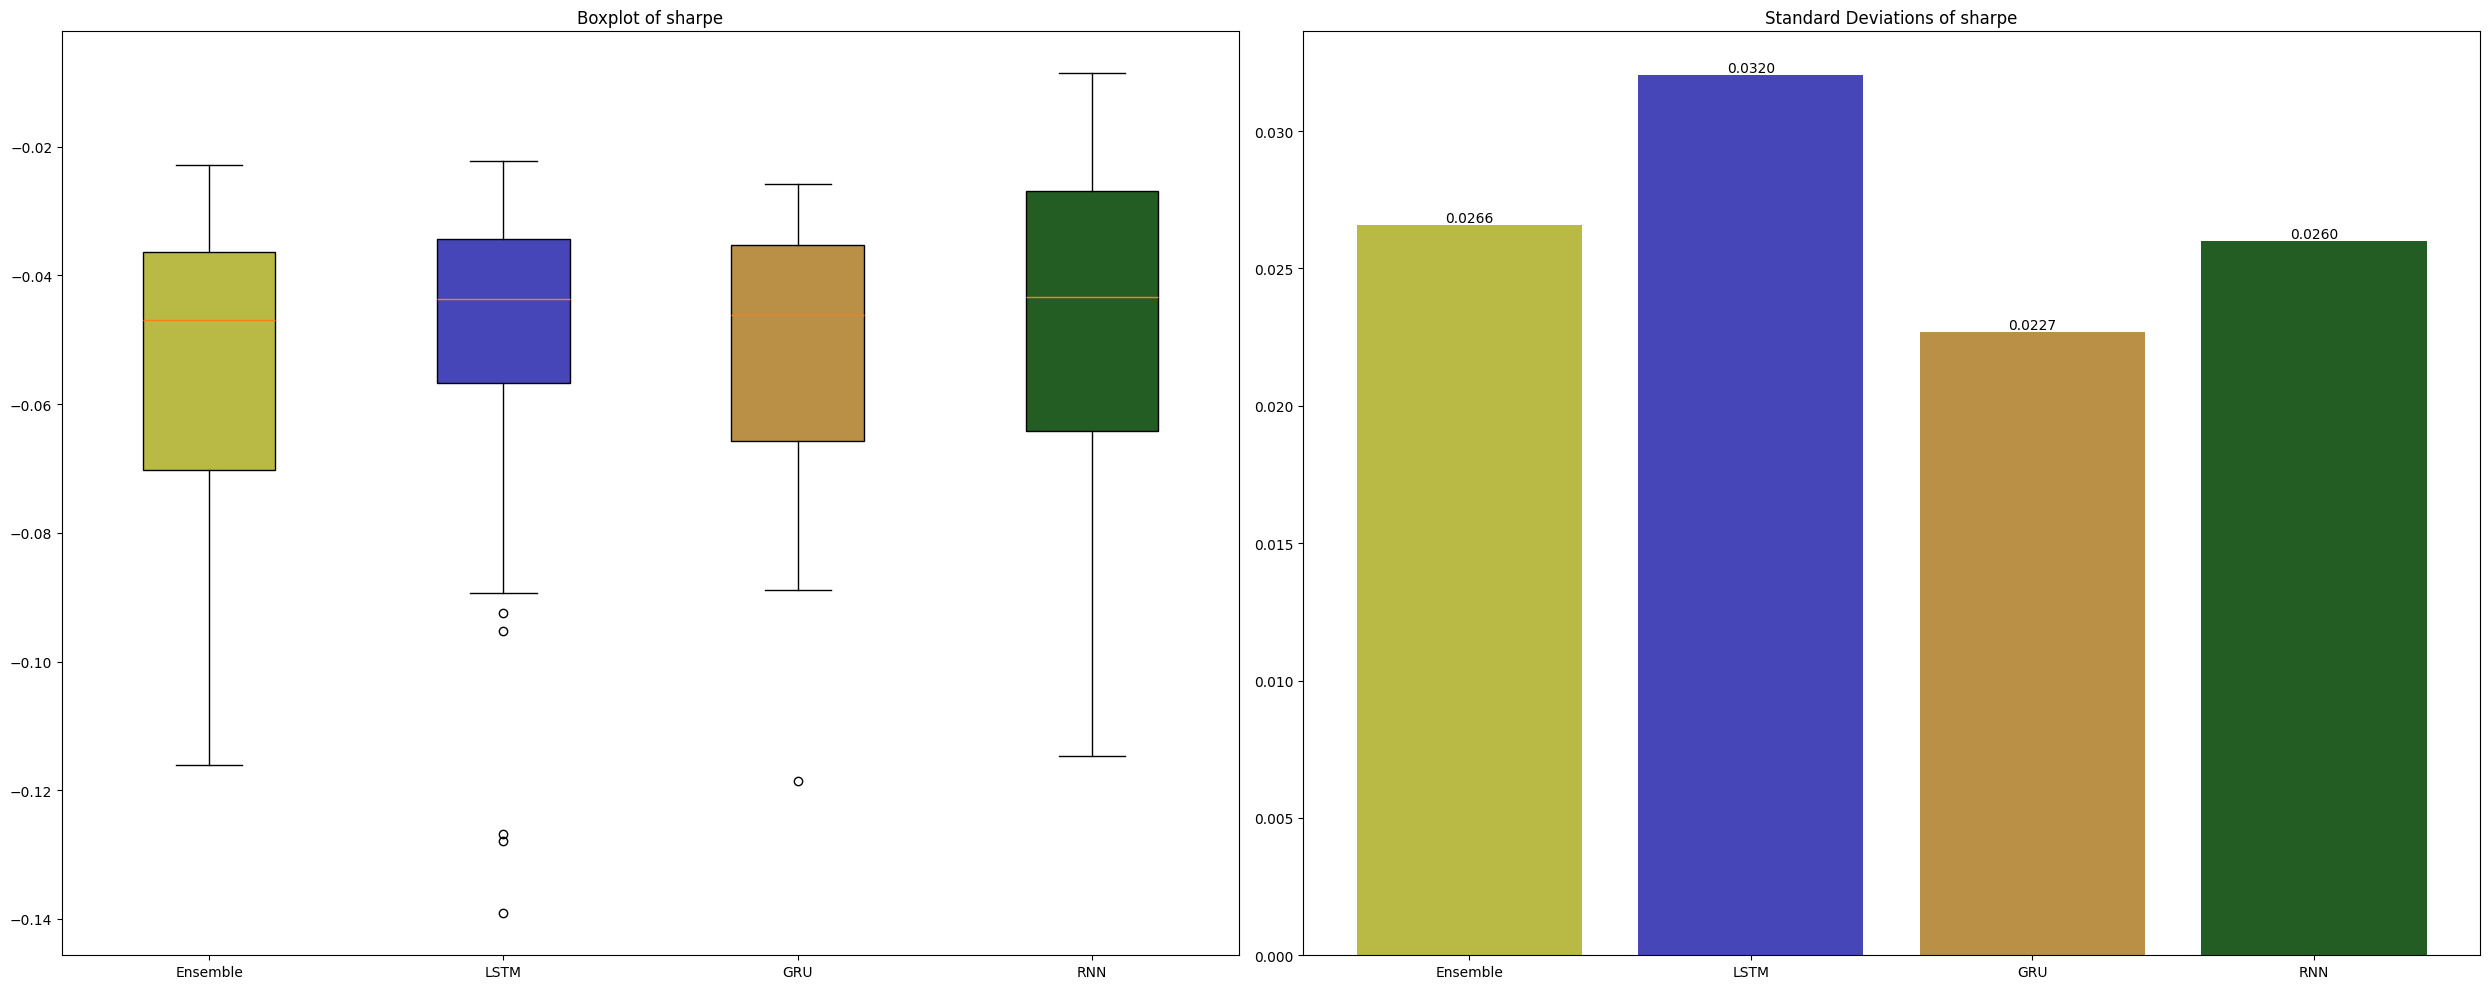

In [40]:
plot_distribution_and_stddev([ensemble_sharpes, lstm_sharpes_1, gru_sharpes_1, rnn_sharpes_1], metric="sharpe", models=["Ensemble", "LSTM", "GRU", "RNN"])

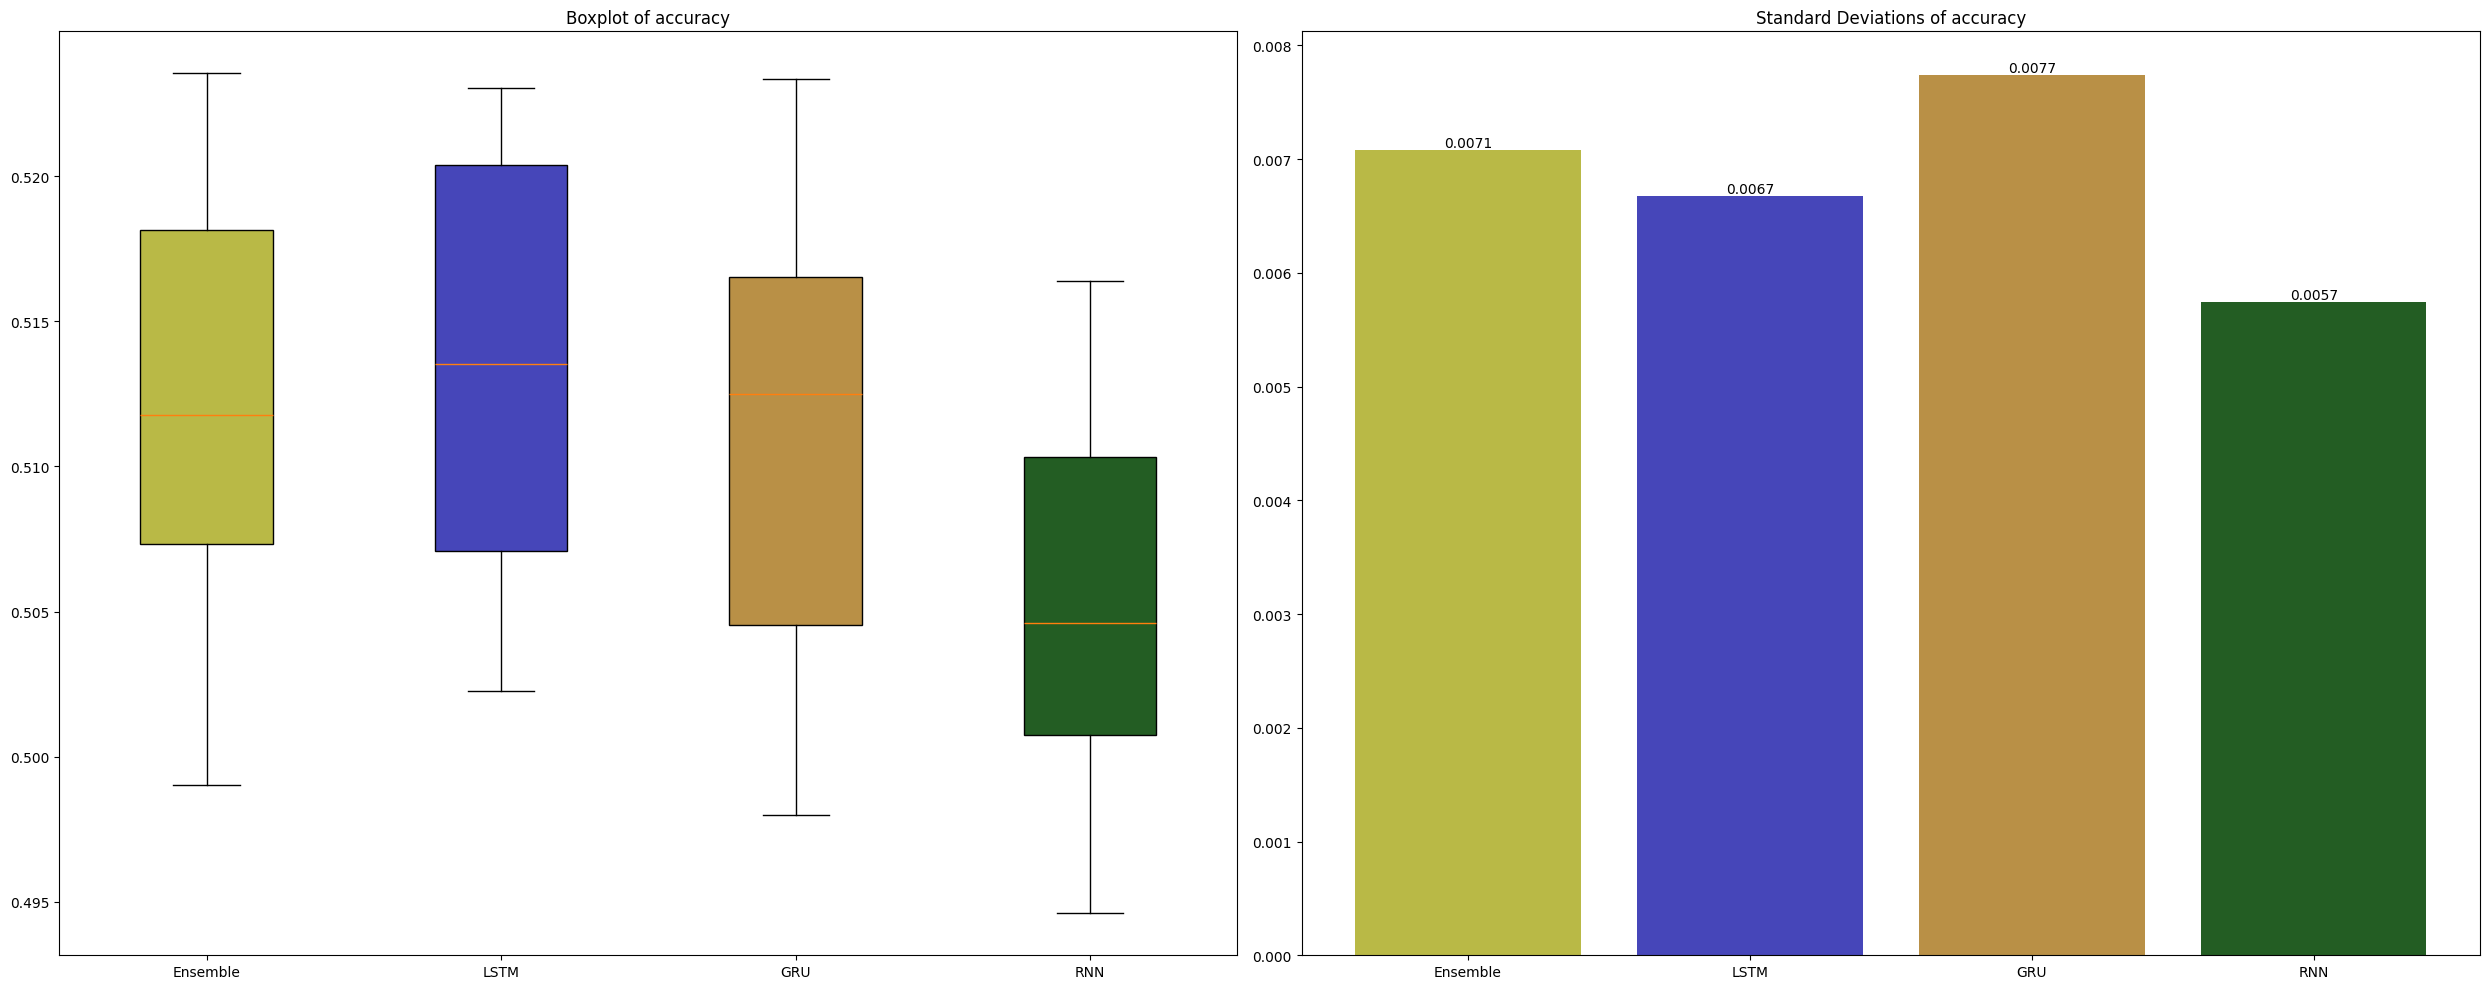

In [41]:
plot_distribution_and_stddev([ensemble_accs, lstm_accs_1, gru_accs_1, rnn_accs_1], metric="accuracy", models=["Ensemble", "LSTM", "GRU", "RNN"])

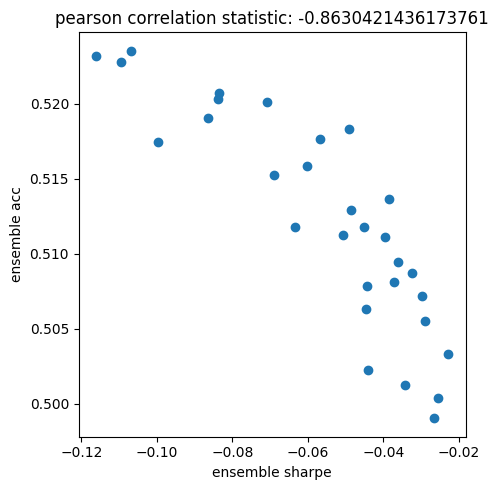

In [42]:
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

x, y = ensemble_sharpes, ensemble_accs
plt.scatter(x, y)
plt.title(f"pearson correlation statistic: {pearsonr(x, y).statistic}")
plt.xlabel(f"ensemble sharpe")
plt.ylabel(f"ensemble acc")

plt.tight_layout()
plt.show()

A mesma correlação negativa entre acurácia e sharpe se repete aqui

## Distribuição de Sharpe e Acurácia em todos os modelos

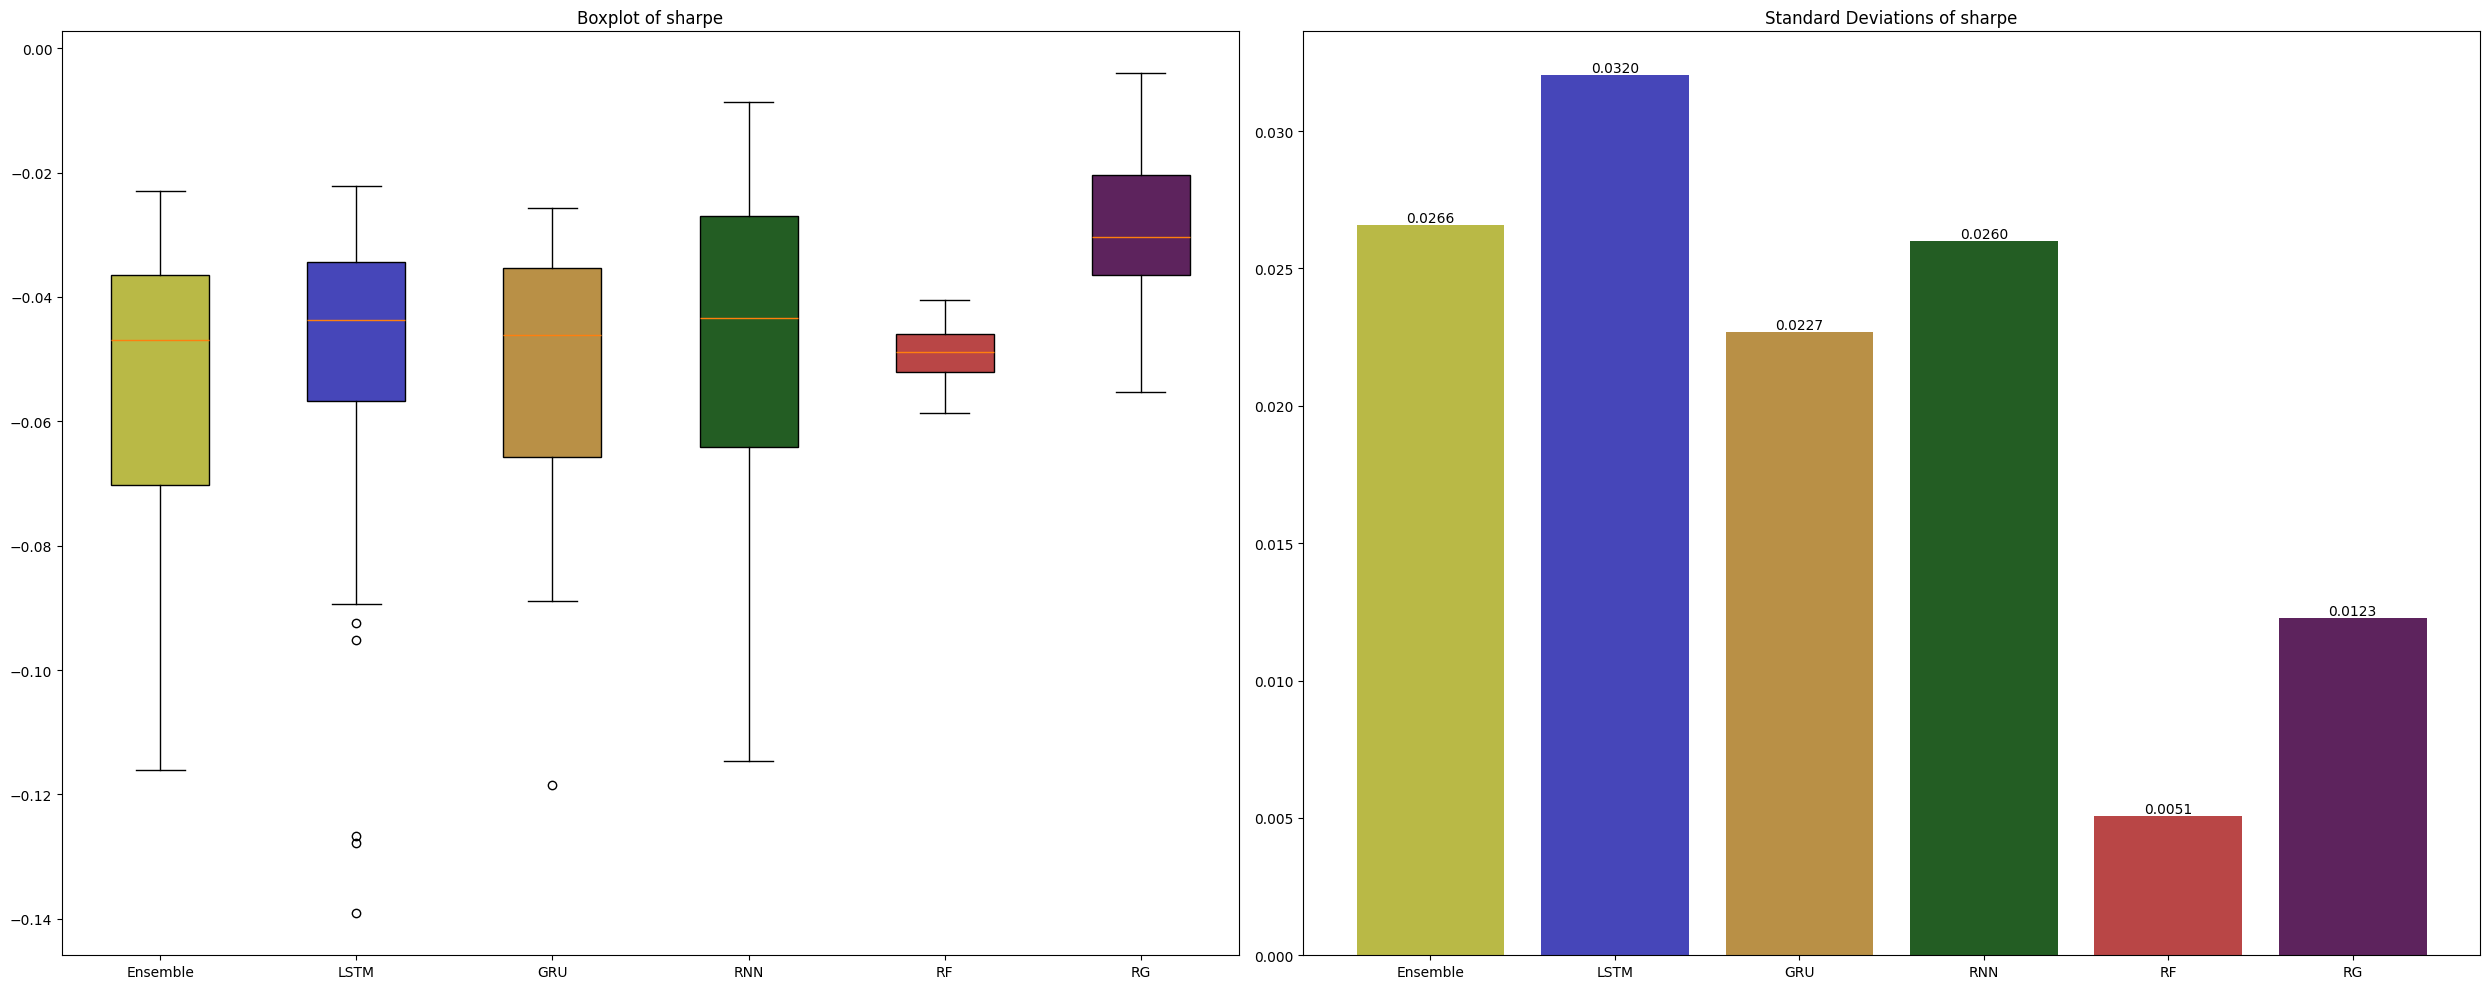

In [43]:
plot_distribution_and_stddev([ensemble_sharpes, lstm_sharpes_1, gru_sharpes_1, rnn_sharpes_1, rf_sharpes_1, rg_sharpes_1], metric="sharpe", models=["Ensemble", "LSTM", "GRU", "RNN", "RF", "RG"])

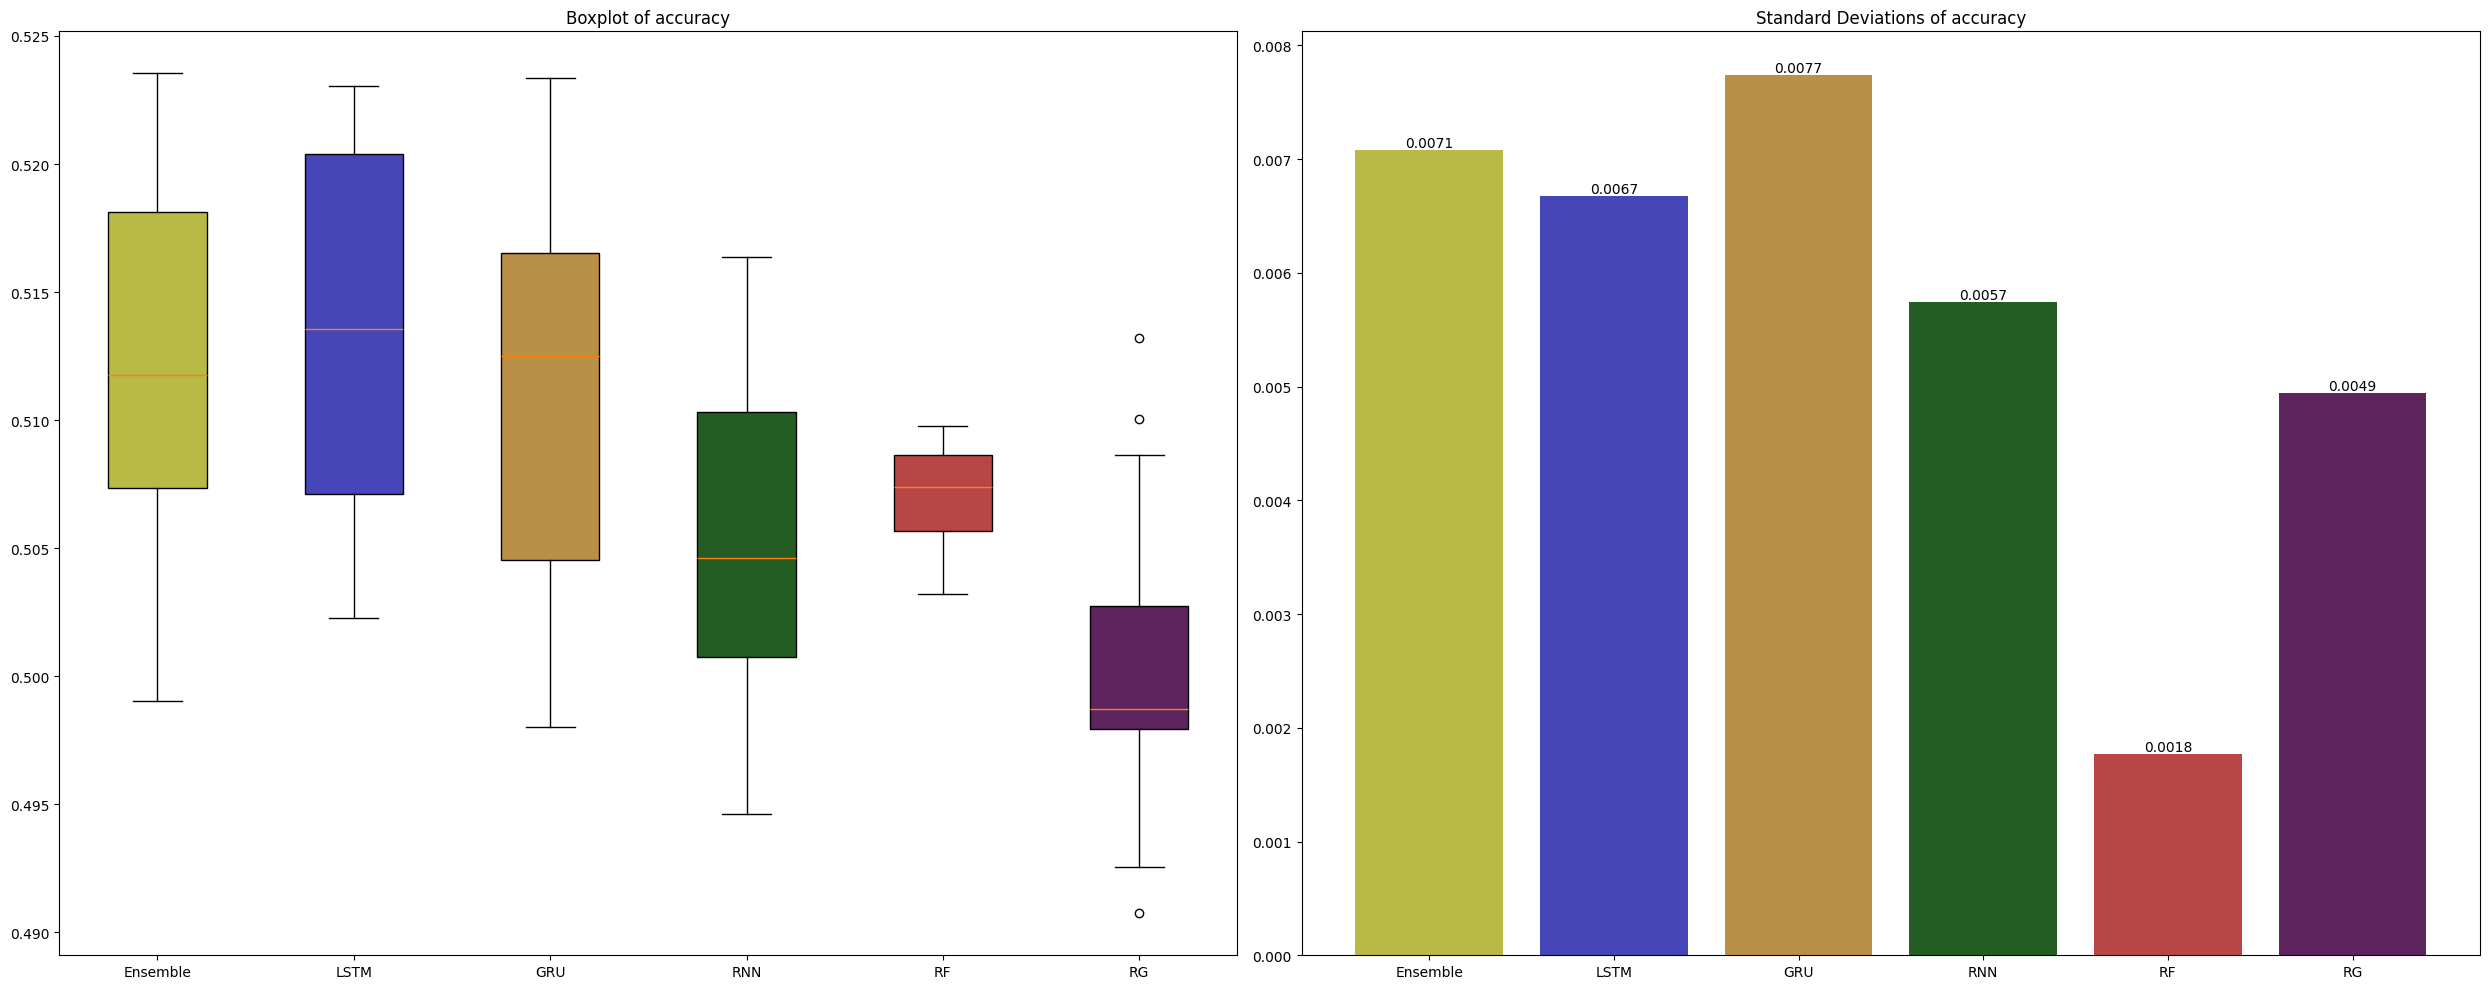

In [44]:
plot_distribution_and_stddev([ensemble_accs, lstm_accs_1, gru_accs_1, rnn_accs_1, rf_accs_1, rg_accs_1], metric="accuracy", models=["Ensemble", "LSTM", "GRU", "RNN", "RF", "RG"])

## Verificando se o Sharpe médio das carteiras dos modelos é pior do que a estratégia B&H - NAO INCLUIR (é óbvio que é melhor, esse teste agrega em nada)

O teste t é utilizado para verificar a nula de que a média de uma amostra é igual, menor que ou maior que uma média suposta. É uma alternativa ao teste Z quando não se conhece o desvio padrão da população e ele precisa ser estimado a partir de uma amostra. Para n <= 30, é necessário que os dados sejam normalmente distribuídos para que o teste t seja confiável. Caso os dados não sejam normalmente distribuídos, será utilizado a contra-parte não paramétrica, o teste de Wilcoxon (Signed-rank). Se aplicado o teste com a alternativa de que a média amostral é MENOR que um valor suposto, e a nula for rejeitada, a evidencia aponta para que a média da distribuição seja significantemente menor que o valor suposto, ou seja, a estratégia Buy and Hold é melhor do que o modelo

In [45]:
list_of_sharpes = [ensemble_sharpes, lstm_sharpes_1, gru_sharpes_1, rnn_sharpes_1, rf_sharpes_1, rg_sharpes_1]
list_of_models = ["Ensemble", "LSTM", "GRU", "RNN", "RF", "RG"]

Ensemble
Shapiro-Wilk Statistic: 0.896917916078673
P-Value: 0.007066166050288382
H0 rejected for an alpha of 0.05, distribution can't be assumed drawn from a Normal


LSTM
Shapiro-Wilk Statistic: 0.8082683794375153
P-Value: 9.30976867226608e-05
H0 rejected for an alpha of 0.05, distribution can't be assumed drawn from a Normal


GRU
Shapiro-Wilk Statistic: 0.9017968342747555
P-Value: 0.009295690132311865
H0 rejected for an alpha of 0.05, distribution can't be assumed drawn from a Normal


RNN
Shapiro-Wilk Statistic: 0.9490798427522944
P-Value: 0.15972415878257068
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


RF
Shapiro-Wilk Statistic: 0.967499551770241
P-Value: 0.47321985111796205
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


RG
Shapiro-Wilk Statistic: 0.9882985823846266
P-Value: 0.9795766188212325
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution




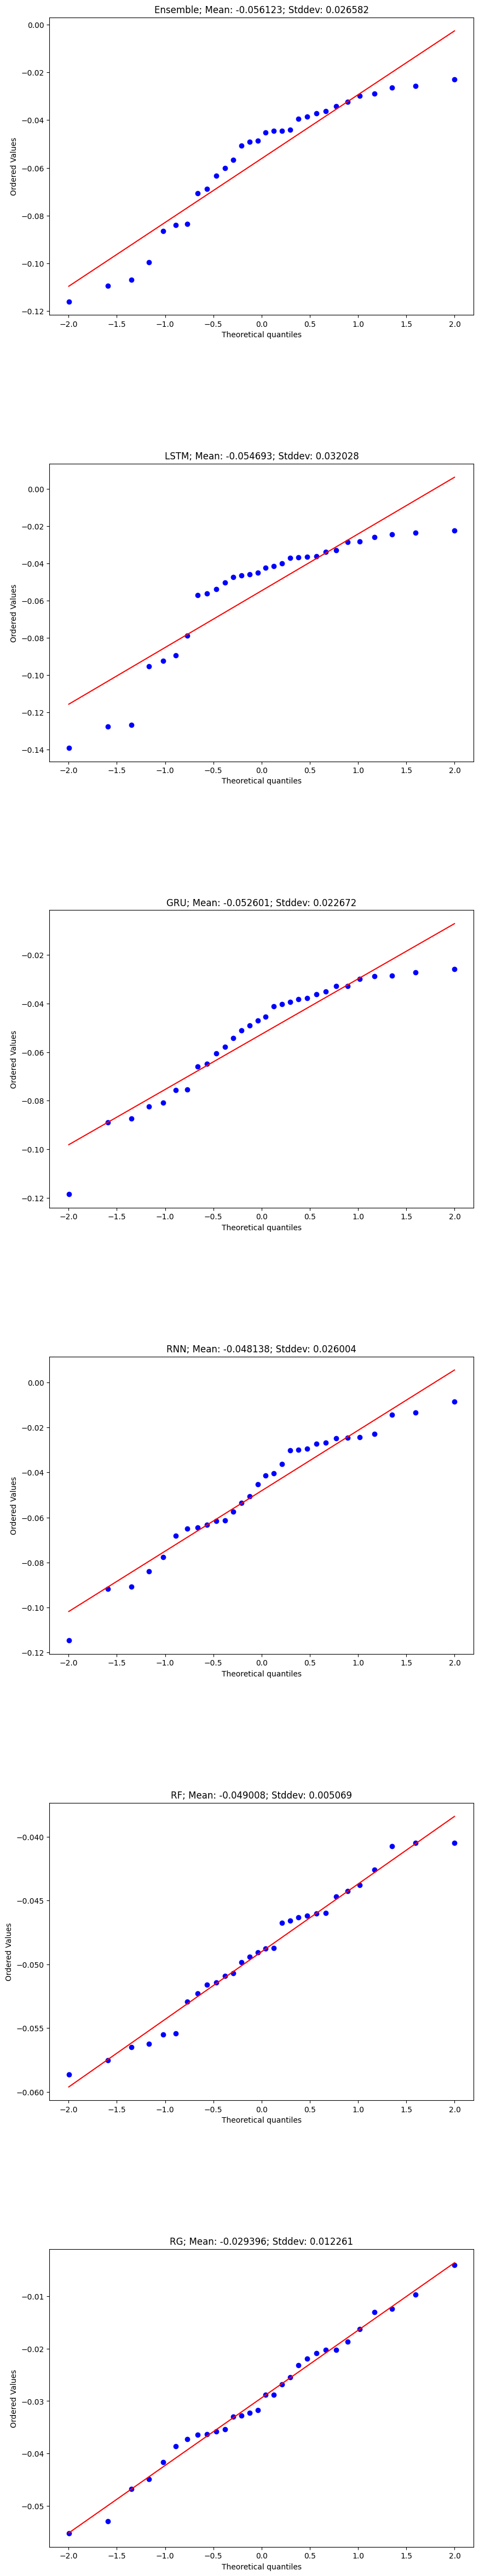

In [46]:
subplot_size = 10 

num_dists = len(list_of_sharpes)
fig_height = subplot_size * num_dists
fig_width = subplot_size

plt.figure(figsize=(fig_width, fig_height))

for i, dist in enumerate(list_of_sharpes):

    print(list_of_models[i])
    shapiro_wilk_gaussian_test(dist)
    print("")
    print("")

    mean = np.array(dist).mean()
    std = np.array(dist).std()

    plt.subplot(len(list_of_sharpes), 1, i+1)
    plt.axis(True)
    probplot(dist, dist="norm", plot=plt)
    plt.title(f"{list_of_models[i]}; Mean: {mean:.6f}; Stddev: {std:.6f}")
    plt.subplots_adjust(wspace=0.2, hspace=0.5)

In [47]:
wilcoxon_pvalues = []
for i, dist in enumerate(list_of_sharpes):
    print(list_of_models[i])
    p = wilcoxon_signed_rank(dist, buy_and_hold_sharpe)
    wilcoxon_pvalues.append(p)
    print("")

# fig, ax = plt.subplots(figsize=(8, 4))
# ax.axis('tight')
# ax.axis('off')
# ax.table(cellText=list_of_models, colLabels=list_of_models)

# plt.title("P-values for Each Model's Test Against Buy and Hold Portfolio", fontsize=14)
# plt.show()

Ensemble
W statistic: 0.0
p-value: 9.313225746154785e-10
Reject H0: the evidence shows that the Sharpes' mean is less than B&H

LSTM
W statistic: 0.0
p-value: 9.313225746154785e-10
Reject H0: the evidence shows that the Sharpes' mean is less than B&H

GRU
W statistic: 0.0
p-value: 9.313225746154785e-10
Reject H0: the evidence shows that the Sharpes' mean is less than B&H

RNN
W statistic: 0.0
p-value: 9.313225746154785e-10
Reject H0: the evidence shows that the Sharpes' mean is less than B&H

RF
W statistic: 0.0
p-value: 9.313225746154785e-10
Reject H0: the evidence shows that the Sharpes' mean is less than B&H

RG
W statistic: 0.0
p-value: 9.313225746154785e-10
Reject H0: the evidence shows that the Sharpes' mean is less than B&H



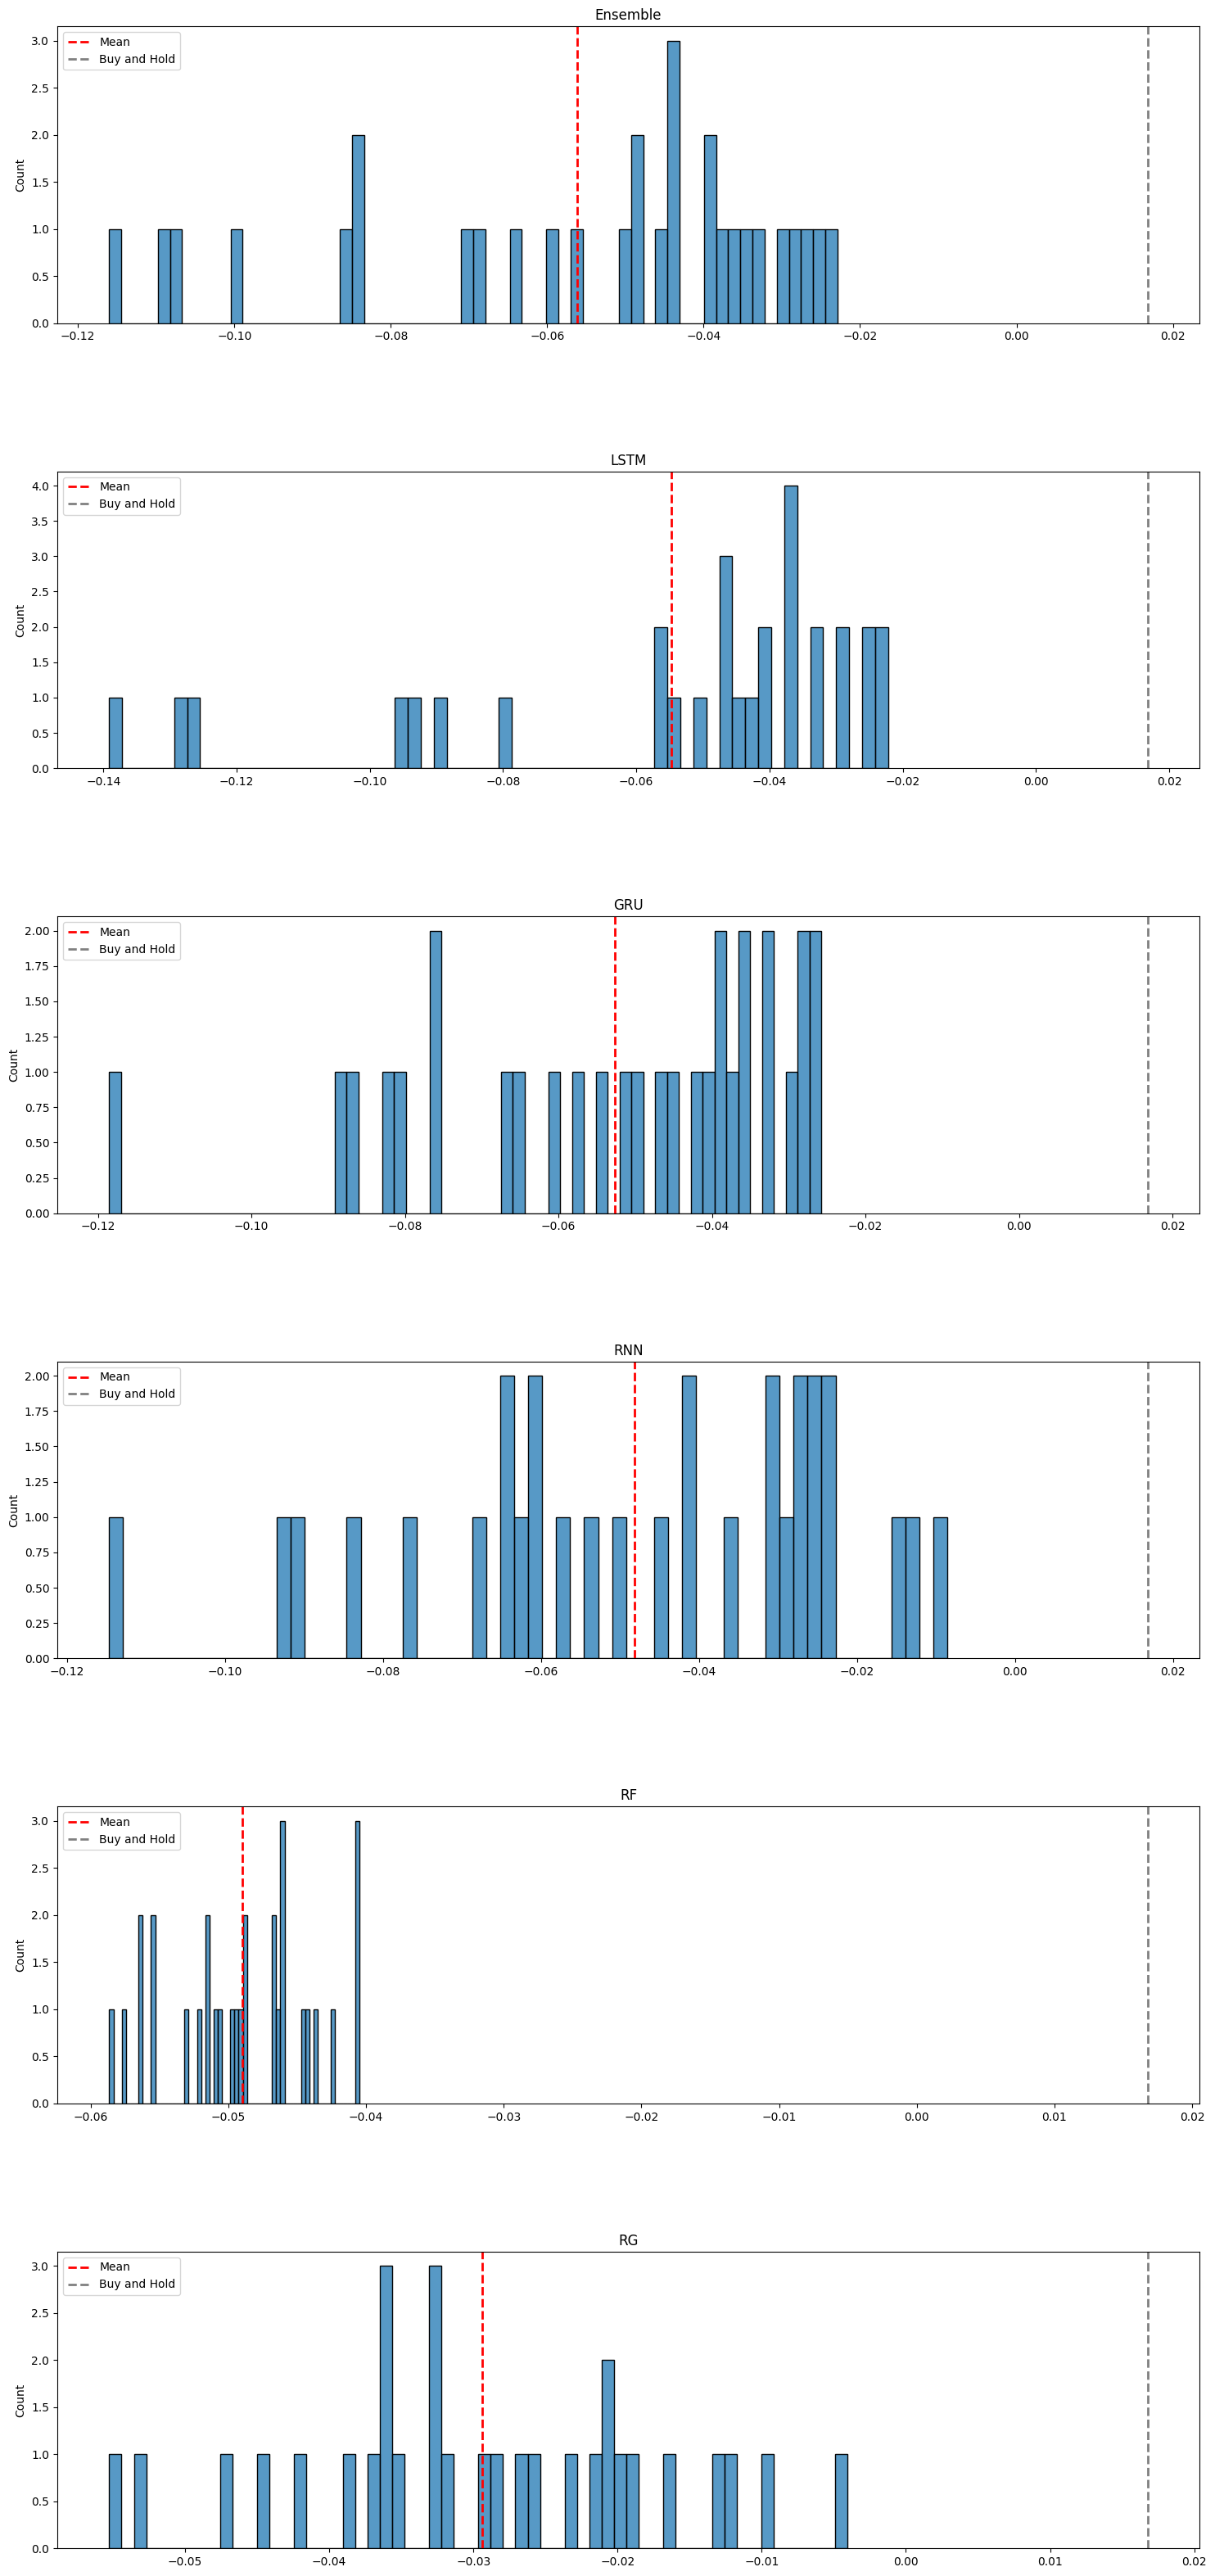

In [48]:
plt.figure(figsize=(18, 40))
for i, dist in enumerate(list_of_sharpes):
    mean = np.mean(dist)

    plt.subplot(len(list_of_sharpes), 1, i+1)
    plt.axis(True)
    sns.histplot(data=dist, kde=False, bins=60)
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean')
    plt.title(f"{list_of_models[i]}")
    plt.axvline(buy_and_hold_sharpe, color='grey', linestyle='dashed', linewidth=2, label=f'Buy and Hold')
    plt.legend(frameon=True)
    plt.subplots_adjust(wspace=0.2, hspace=0.5)

## Verificando diferença significativa nas acurácias - teste de kruskal-wallis - TALVEZ INCLUIR (mas seria bom mudar a visualização dos p-values pairwise pra focar na diferença entre modelo aleatorio e os outros)

Para verificar se os modelos apresentam acurácias significantemente diferentes entre si, será aplicado um teste de hipótese para diferença entre distribuições de acurácias. Para selecionar o teste apropriado, deve-se verificar as suposições que o ANOVA realiza, e caso não os cumpra, o Kruskal-Wallis será utilizado, que estende o teste Mann-Whitney-U para vários grupos. As suposições principais são de normalidade e homoscedasticidade (variancias iguais)

In [49]:
list_of_dists = [ensemble_accs, lstm_accs_1, gru_accs_1, rnn_accs_1, rf_accs_1, rg_accs_1]

Testando normalidade...

Shapiro-Wilk Statistic: 0.96310925906646
P-Value: 0.37101298980021846
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


Shapiro-Wilk Statistic: 0.9256551872671304
P-Value: 0.03769133777832914
H0 rejected for an alpha of 0.05, distribution can't be assumed drawn from a Normal


Shapiro-Wilk Statistic: 0.9425971151353538
P-Value: 0.10686425723847465
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


Shapiro-Wilk Statistic: 0.9729142396538568
P-Value: 0.621587834058798
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


Shapiro-Wilk Statistic: 0.9547363625397771
P-Value: 0.2259927974112887
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution


Shapiro-Wilk Statistic: 0.9522010647494031
P-Value: 0.1935748495791183
Fail to reject H0 for an alpha of 0.05, possibly drawn from a Normal distribution




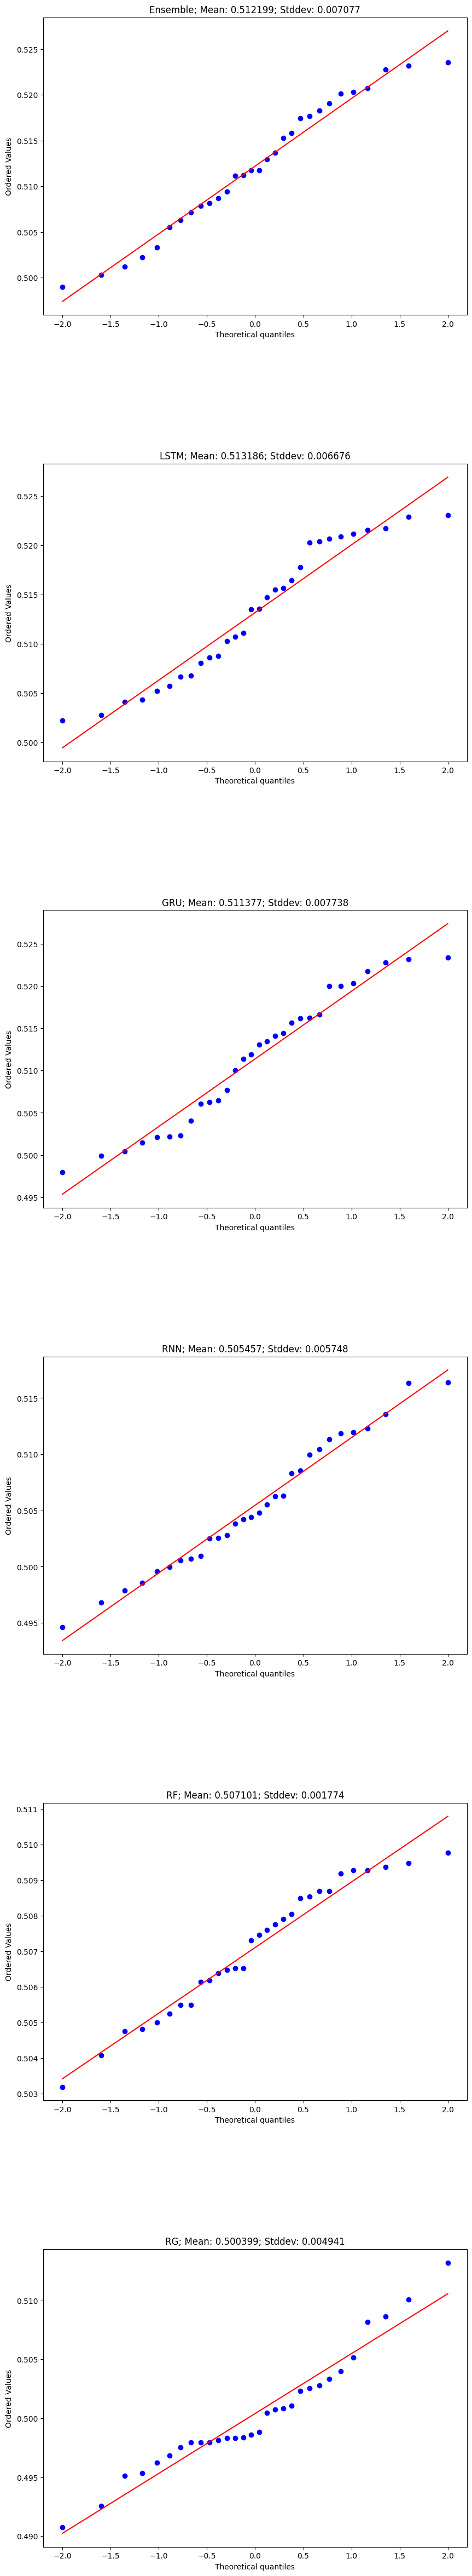

In [67]:
subplot_size = 10 

num_dists = len(list_of_dists)
fig_height = subplot_size * num_dists
fig_width = subplot_size

plt.figure(figsize=(fig_width, fig_height))

for i, dist in enumerate(list_of_dists):

    shapiro_wilk_gaussian_test(dist)
    print("")
    print("")

    mean = np.array(dist).mean()
    std = np.array(dist).std()

    plt.subplot(len(list_of_dists), 1, i+1)
    plt.axis(True)
    probplot(dist, dist="norm", plot=plt)
    plt.title(f"{list_of_models[i]}; Mean: {mean:.6f}; Stddev: {std:.6f}")
    plt.subplots_adjust(wspace=0.2, hspace=0.5)

Testando variância...

In [68]:
# LEVENE
lev_stat, lev_p_value = levene(*list_of_dists)

alpha = 0.05

print(f"Levene's Test statistic: {lev_stat}, p-value: {lev_p_value}")

if lev_p_value < alpha:
    print("Variances are significantly different (reject null hypothesis).")
else:
    print("No significant difference in variances (fail to reject null hypothesis).")

# BARTLETT
bartlett_stat, bart_p_value = bartlett(*list_of_dists)

print(f"Bartlett's Test statistic: {bartlett_stat}, p-value: {bart_p_value}")

if bart_p_value < alpha:
    print("Variances are significantly different (reject null hypothesis).")
else:
    print("No significant difference in variances (fail to reject null hypothesis).")

Levene's Test statistic: 9.574178565719423, p-value: 4.360718252091562e-08
Variances are significantly different (reject null hypothesis).
Bartlett's Test statistic: 52.49281399189183, p-value: 4.274395722790211e-10
Variances are significantly different (reject null hypothesis).


Nem todas as distribuições de acurácias seguem uma distribuição normal, além de que a suposição da homoscedasticidade é totalmente violada, então será utilizado a alternativa não-paramétrica

In [84]:
kruskal_wallis_test(list_of_dists)

H-statistic: 62.345861866508685
p-value: 3.976707157801703e-12
There is a significant difference between at least two groups for an alpha of 0.05


Foi verificado que há diferença significativa entre pelo menos dois grupos, então será aplicado um teste post-hoc com correção de Bonferroni para evitar erro tipo I, falsos positivos, ou incorretamente rejeitar H0

In [69]:
group_rename_map = {1: 'Ensemble Acc', 2: 'LSTM Acc', 3: 'GRU Acc', 4: 'RNN Acc', 5: 'RF Acc', 6: 'RG Acc'}

posthoc_results = posthoc_dunn(list_of_dists, p_adjust='bonferroni')
posthoc_results.rename(index=group_rename_map, columns=group_rename_map, inplace=True)

print(f"Pairwise Dunn's test results (Bonferroni corrected p-values):\n {posthoc_results.to_string()}")

Pairwise Dunn's test results (Bonferroni corrected p-values):
               Ensemble Acc      LSTM Acc       GRU Acc   RNN Acc    RF Acc        RG Acc
Ensemble Acc  1.000000e+00  1.000000e+00  1.000000e+00  0.010697  0.290108  1.405439e-08
LSTM Acc      1.000000e+00  1.000000e+00  1.000000e+00  0.001717  0.073821  6.464272e-10
GRU Acc       1.000000e+00  1.000000e+00  1.000000e+00  0.072692  1.000000  4.226295e-07
RNN Acc       1.069739e-02  1.716881e-03  7.269193e-02  1.000000  1.000000  9.347799e-02
RF Acc        2.901081e-01  7.382136e-02  1.000000e+00  1.000000  1.000000  2.343998e-03
RG Acc        1.405439e-08  6.464272e-10  4.226295e-07  0.093478  0.002344  1.000000e+00


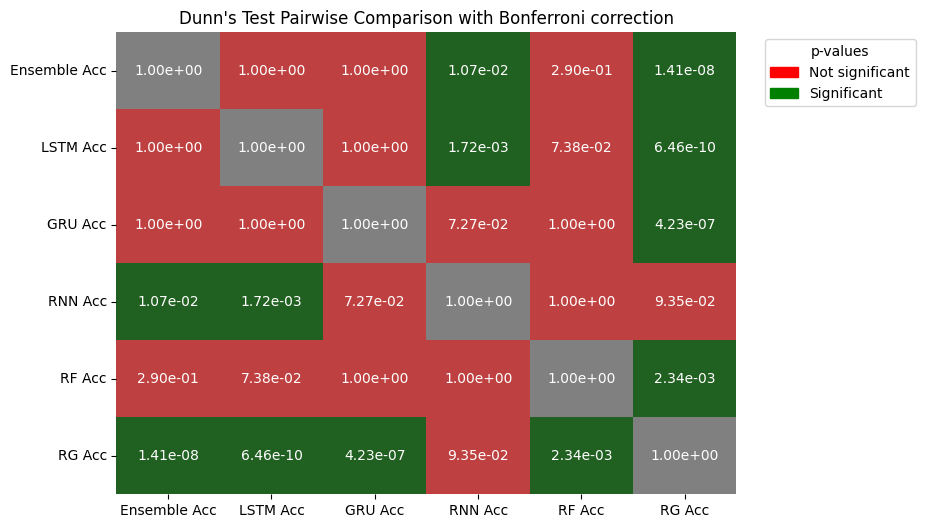

In [ ]:
# Convert DataFrame to NumPy array
p_values = posthoc_results.to_numpy()

# Create a color mask
colors = np.full(p_values.shape, "", dtype=object)

# Apply colors
for i in range(p_values.shape[0]):
    for j in range(p_values.shape[1]):
        if i == j:
            colors[i, j] = adjust_saturation('grey')  # Grey for diagonal
        elif p_values[i, j] > 0.05:
            colors[i, j] = adjust_saturation('red')  # Not significant (p > 0.05)
        else:
            colors[i, j] = adjust_saturation('green')  # Significant (p ≤ 0.05)

# Plot using seaborn heatmap
plt.figure(figsize=(8, 6))

# Define custom patches
legend_patches = [
    mpatches.Patch(color="red", label="Not significant"),
    mpatches.Patch(color="green", label="Significant")
]

# Add legend to the plot
plt.legend(handles=legend_patches, title="p-values", loc="upper right", bbox_to_anchor=(1.3, 1))

ax = sns.heatmap(posthoc_results, annot=True, fmt=".2e", cmap=['green', 'grey', 'red'], cbar=False)
plt.legend

# Apply custom face color to each cell
for i in range(p_values.shape[0]):
    for j in range(p_values.shape[1]):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color=colors[i, j], lw=0))

plt.title("Dunn's Test Pairwise Comparison with Bonferroni correction")

# Show plot
plt.show()

TODO: trocar isso por um teste par a par entre aleatorio e os outros. Do jeito que está nao agrega muito, não me interessa saber a diferença entre todos

## Distribuição de Classes Preditas - TALVEZ incluir junto com o argumento de que um recall melhor acarreta em um sharpe melhor (FN não ser tao prejudicial) e se incluir, verificar a distribuição sem ser no melhor exp tb

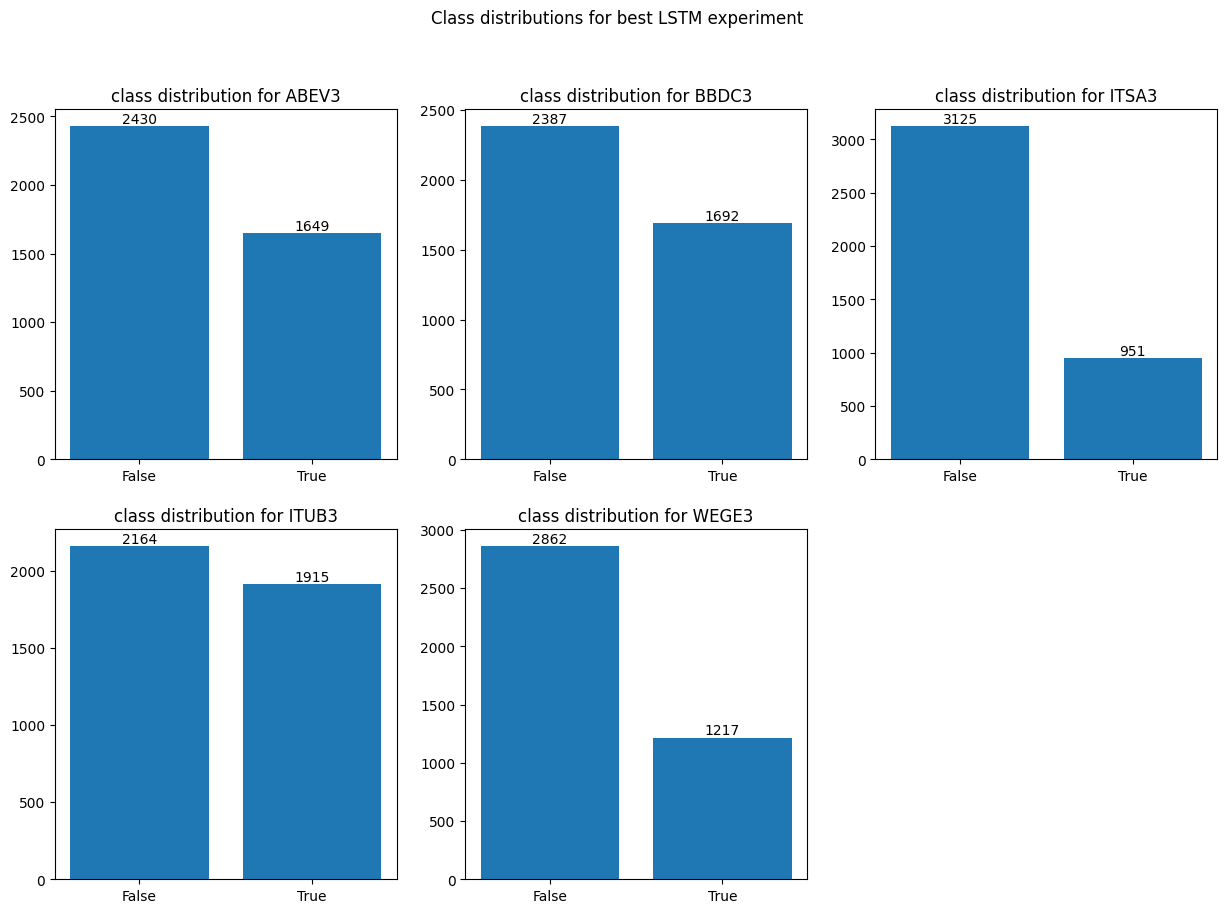

In [71]:
print_class_distributions_for_experiment(results_lstm_1, best_exp_idx_lstm, "LSTM", stocks)

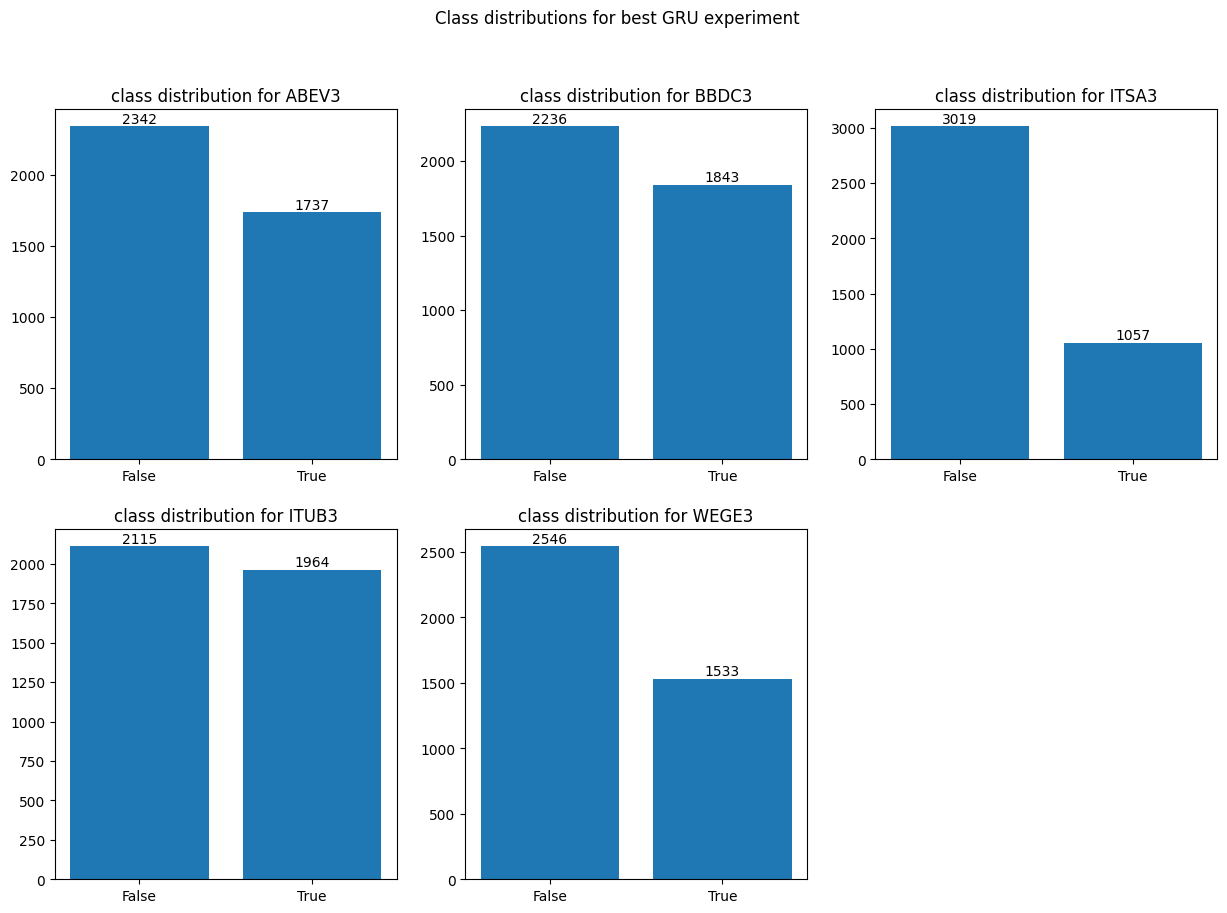

In [72]:
print_class_distributions_for_experiment(results_gru_1, best_exp_idx_gru, "GRU", stocks)

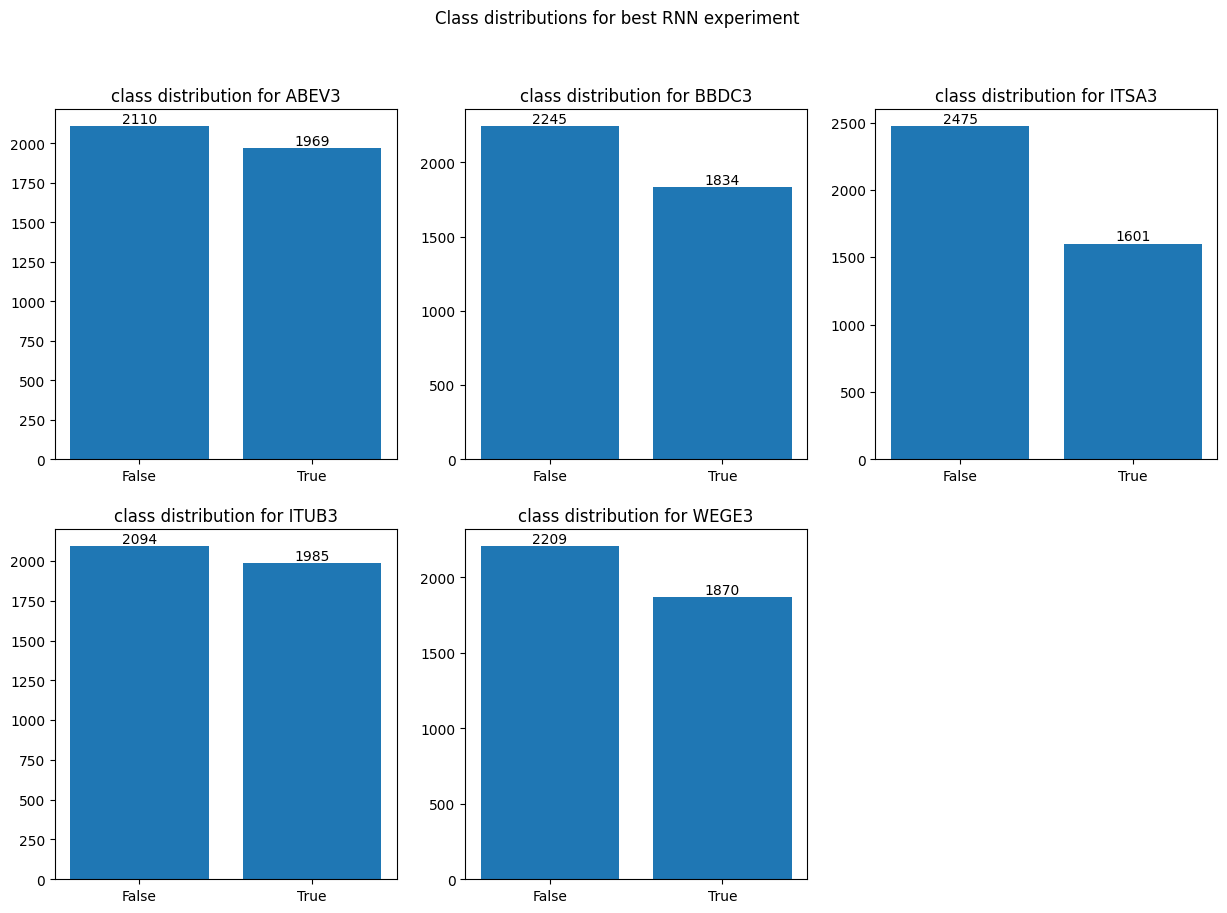

In [73]:
print_class_distributions_for_experiment(results_rnn_1, best_exp_idx_rnn, "RNN", stocks)

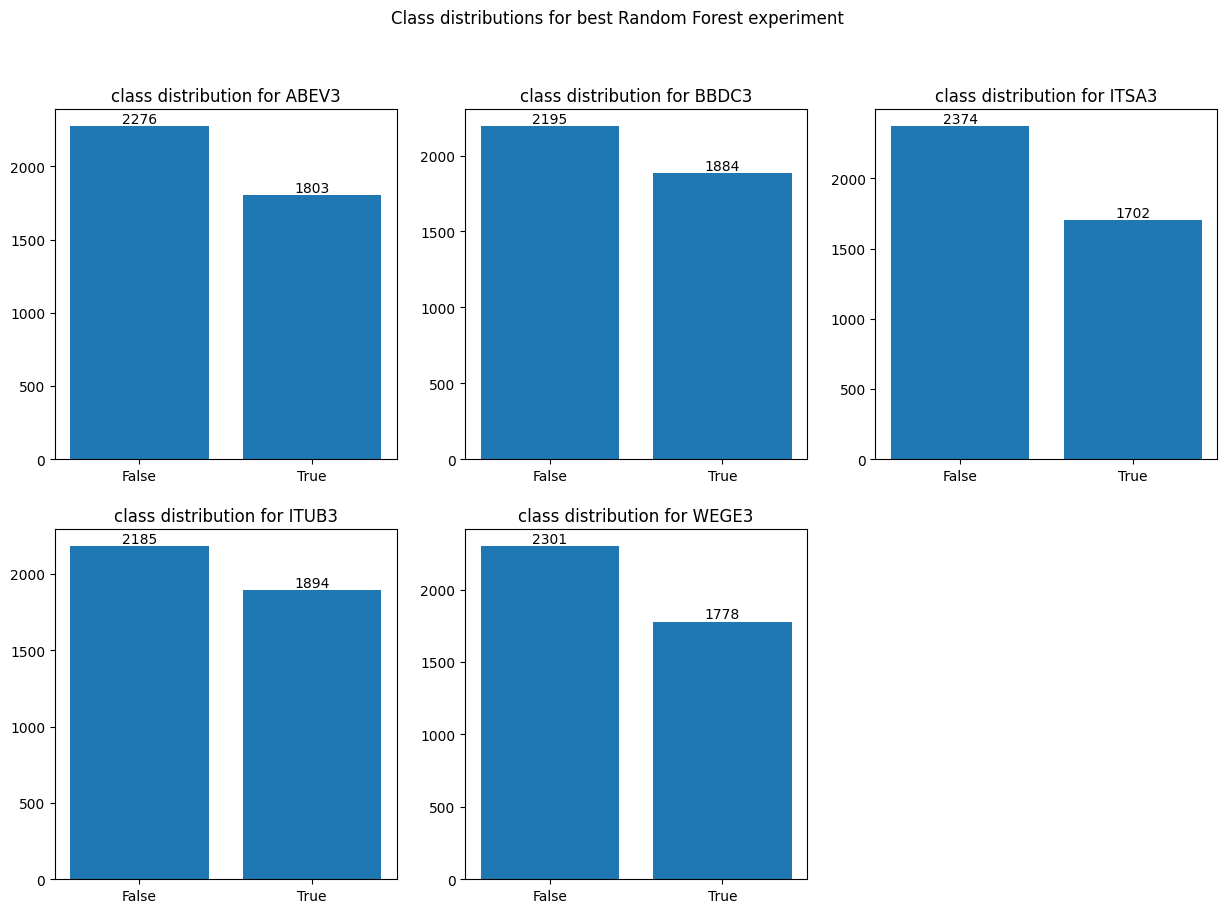

In [74]:
print_class_distributions_for_experiment(results_rf_1, best_exp_idx_rf, "Random Forest", stocks)

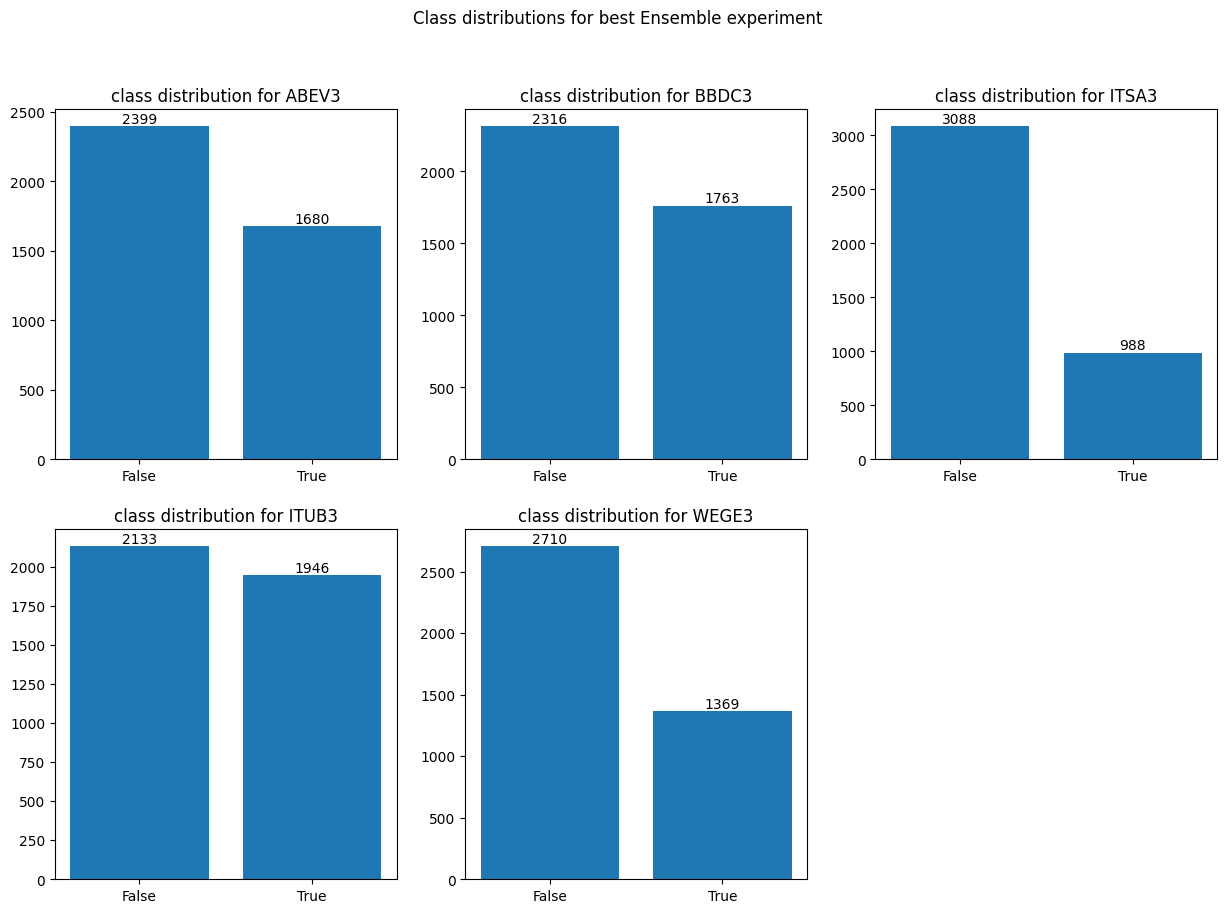

In [75]:
print_class_distributions_for_experiment(res_ensemble, best_exp_idx_ensemble, "Ensemble", stocks)

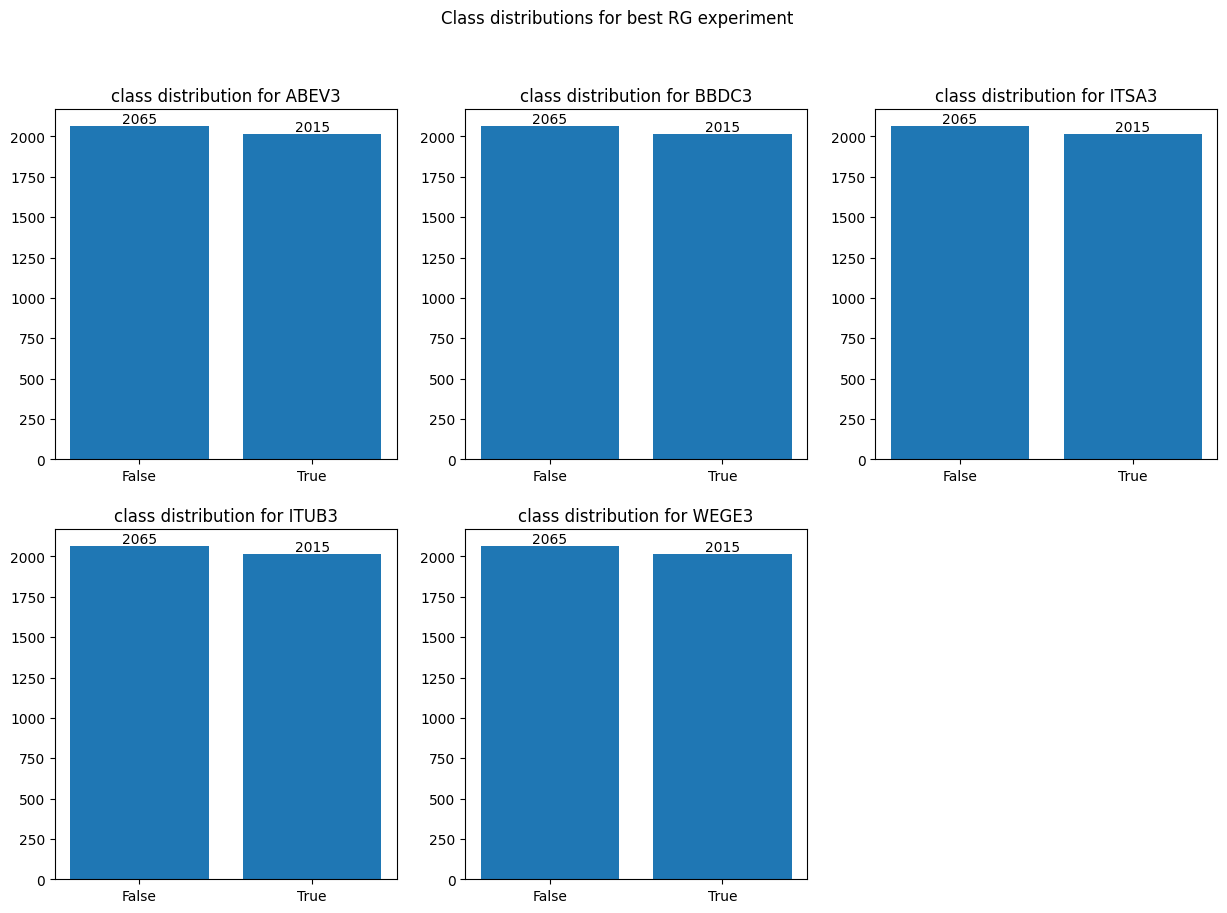

In [76]:
print_class_distributions_for_experiment(results_rg_1, best_exp_idx_rg, "RG", stocks)

## Retornos cumulativos médios e distribuídos

In [77]:
lstm_mean_cuml_returns, lstm_std_cuml_returns = get_mean_cuml_returns_across_exps(results_lstm_1, daily_returns)
gru_mean_cuml_returns, gru_std_cuml_returns = get_mean_cuml_returns_across_exps(results_gru_1, daily_returns)
rnn_mean_cuml_returns, rnn_std_cuml_returns = get_mean_cuml_returns_across_exps(results_rnn_1, daily_returns)
rf_mean_cuml_returns, rf_std_cuml_returns = get_mean_cuml_returns_across_exps(results_rf_1, daily_returns)
rg_mean_cuml_returns, rg_std_cuml_returns = get_mean_cuml_returns_across_exps(results_rg_1, daily_returns)
ensemble_mean_cuml_returns, ensemble_std_cuml_returns = get_mean_cuml_returns_across_exps(res_ensemble, daily_returns)

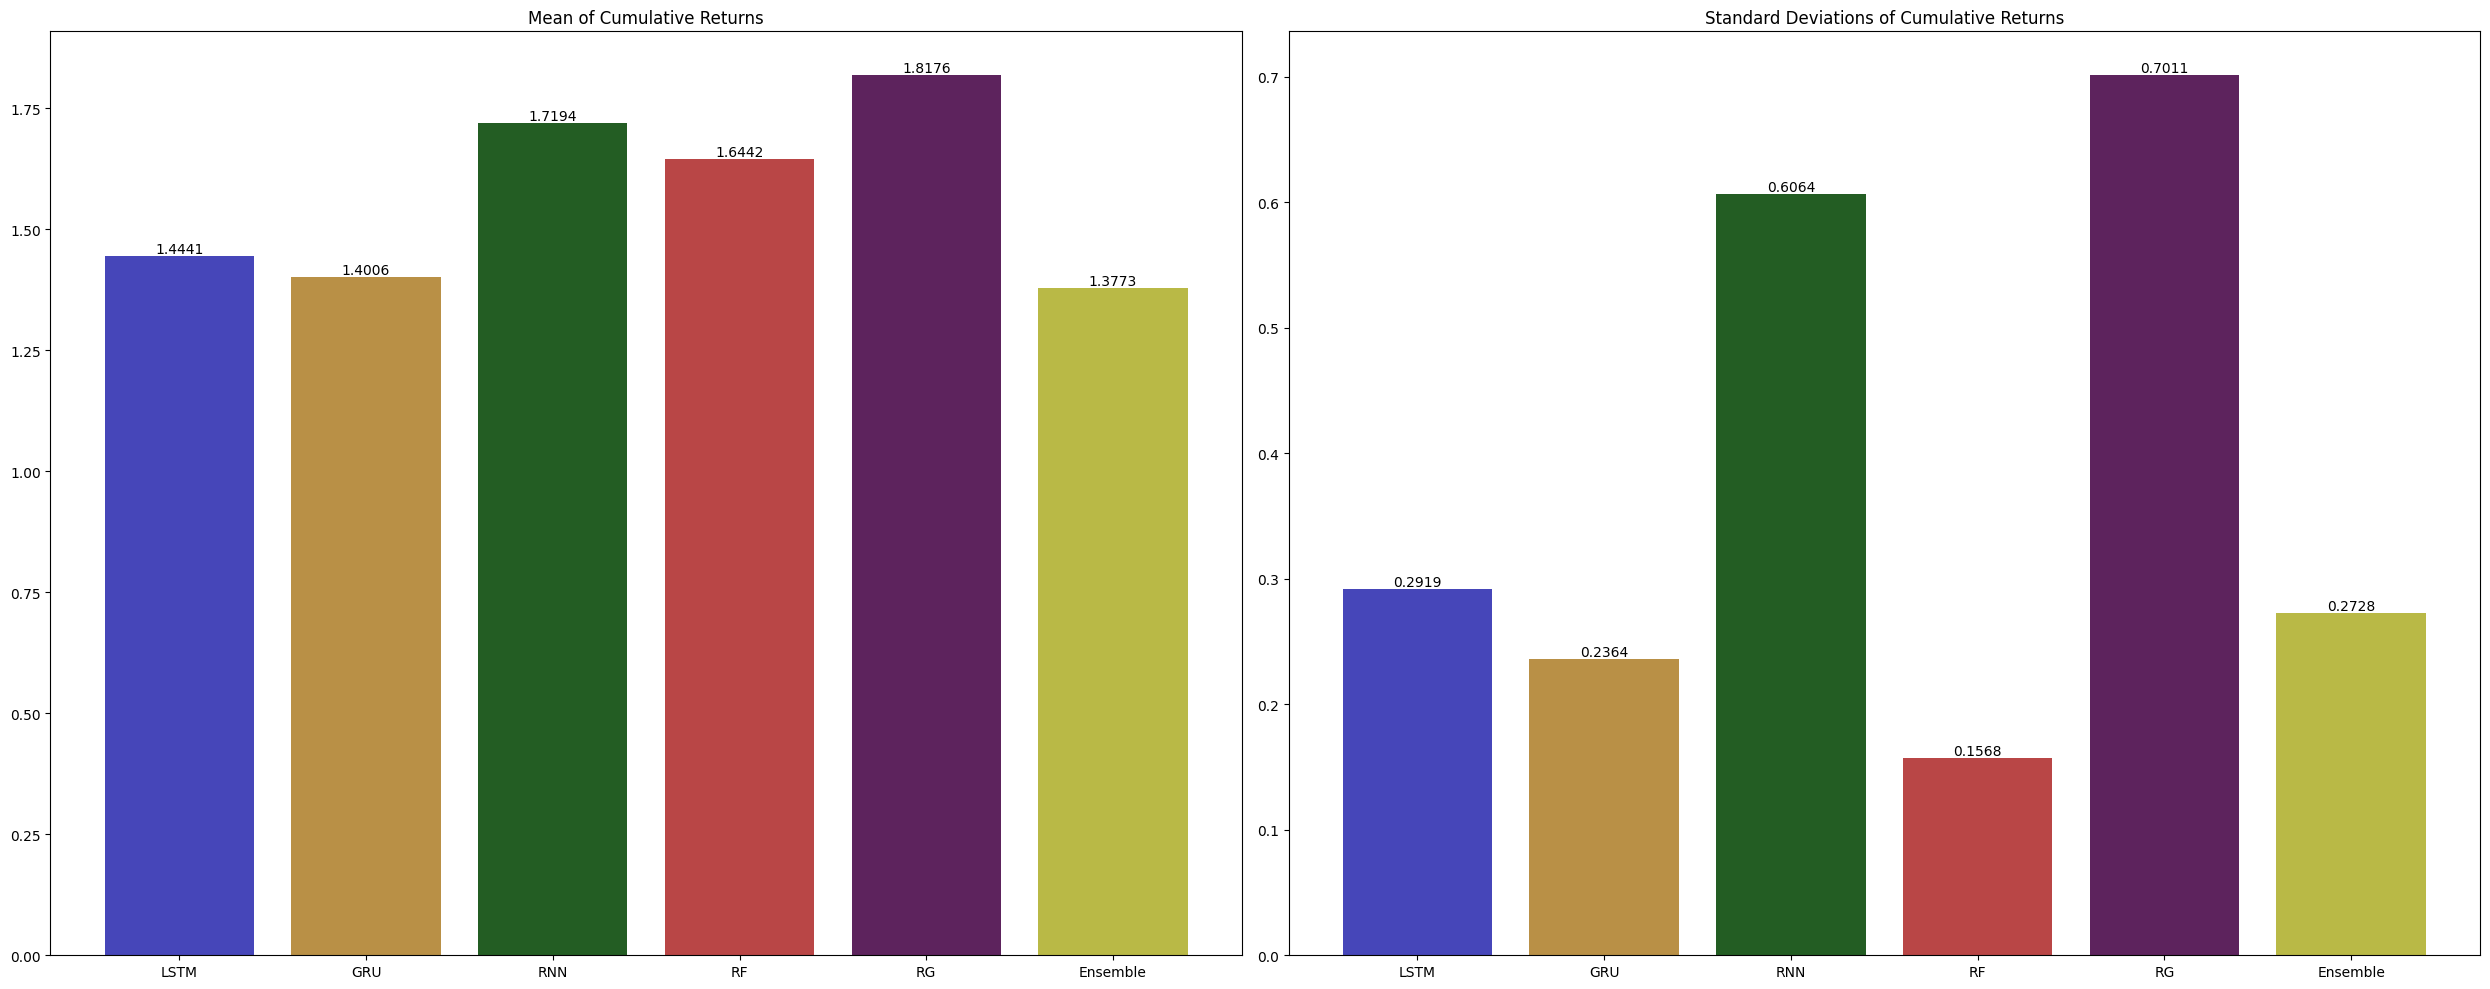

In [78]:
plot_mean_and_stddev([
    lstm_mean_cuml_returns,
    gru_mean_cuml_returns,
    rnn_mean_cuml_returns,
    rf_mean_cuml_returns,
    rg_mean_cuml_returns,
    ensemble_mean_cuml_returns
], [
    lstm_std_cuml_returns,
    gru_std_cuml_returns,
    rnn_std_cuml_returns,
    rf_std_cuml_returns,
    rg_std_cuml_returns,
    ensemble_std_cuml_returns
], "Cumulative Returns")

In [79]:
lstm_cuml_returns_dist = get_cuml_returns_dist(results_lstm_1, daily_returns)
gru_cuml_returns_dist = get_cuml_returns_dist(results_gru_1, daily_returns)
rnn_cuml_returns_dist = get_cuml_returns_dist(results_rnn_1, daily_returns)
rf_cuml_returns_dist = get_cuml_returns_dist(results_rf_1, daily_returns)
rg_cuml_returns_dist = get_cuml_returns_dist(results_rg_1, daily_returns)
ensemble_cuml_returns_dist = get_cuml_returns_dist(res_ensemble, daily_returns)

In [80]:
list_of_models

['Ensemble', 'LSTM', 'GRU', 'RNN', 'RF', 'RG']

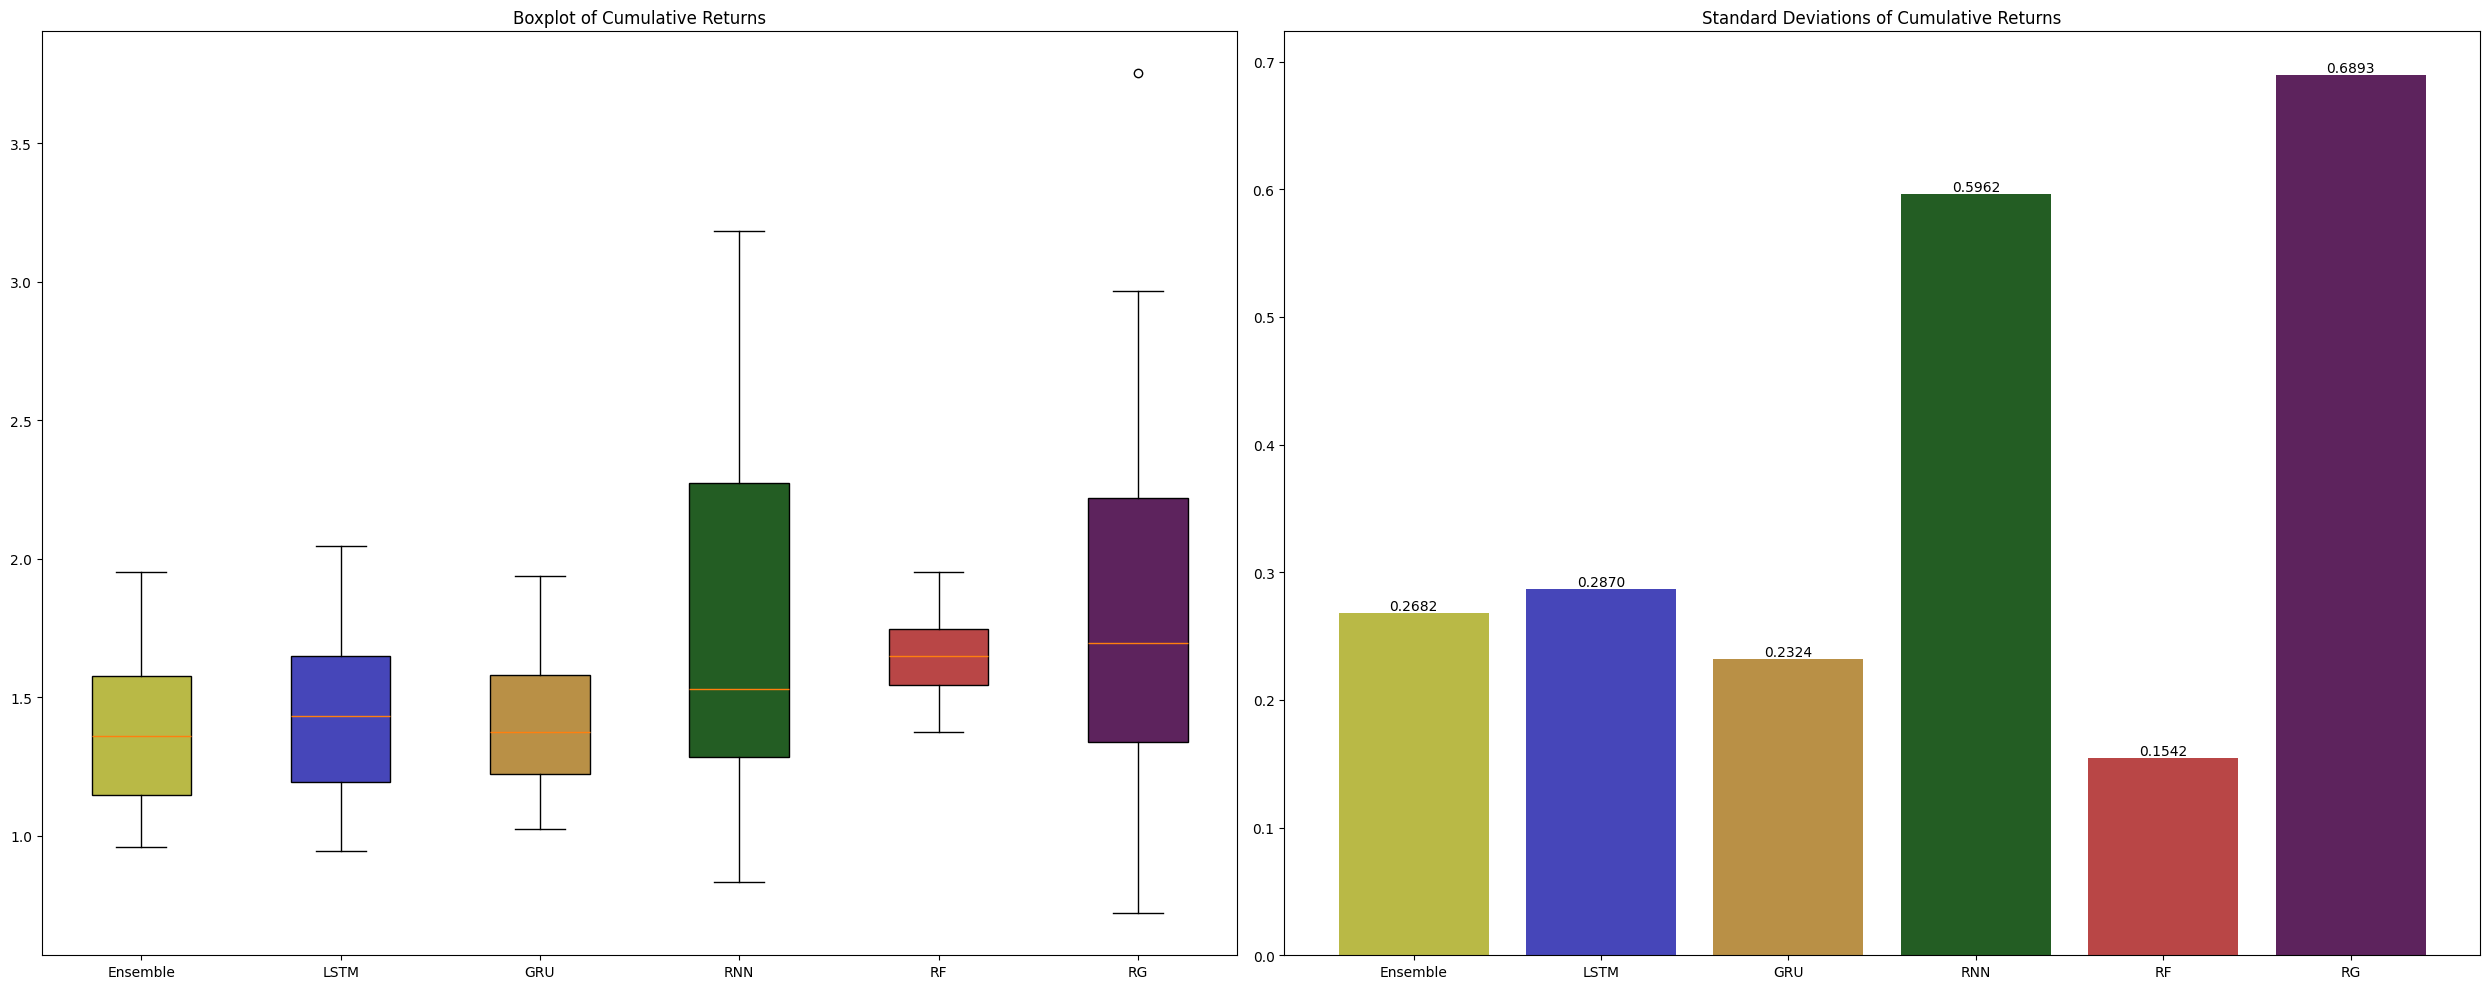

In [81]:
plot_distribution_and_stddev([
    ensemble_cuml_returns_dist,
    lstm_cuml_returns_dist,
    gru_cuml_returns_dist,
    rnn_cuml_returns_dist,
    rf_cuml_returns_dist,
    rg_cuml_returns_dist
],
    "Cumulative Returns",
    models=list_of_models
)

In [82]:
print_statistics_table_for_series([
    ensemble_cuml_returns_dist,
    lstm_cuml_returns_dist,
    gru_cuml_returns_dist,
    rnn_cuml_returns_dist,
    rf_cuml_returns_dist,
    rg_cuml_returns_dist
], models=list_of_models)

+----------+--------------------+--------------------+--------------------+--------------------+---------------------+--------------------+
|  model   |        mean        |       median       |        max         |        min         |        stddev       |     full range     |
+----------+--------------------+--------------------+--------------------+--------------------+---------------------+--------------------+
| Ensemble | 1.377314697798346  | 1.361933934613853  | 1.9533076374386527 | 0.958705309682192  |  0.2681984031159909 | 0.9946023277564606 |
|   LSTM   | 1.4440844108432063 | 1.431471251593191  | 2.0461796079353913 | 0.944169980470724  | 0.28702858396079756 | 1.1020096274646674 |
|   GRU    | 1.4006093844042489 | 1.3747897205169932 | 1.9389451381464355 | 1.0265053065829262 |  0.2324177807897227 | 0.9124398315635094 |
|   RNN    | 1.7194211852533525 | 1.5318674616803085 | 3.1855704644701563 | 0.8332742850554803 |  0.5961844038487321 | 2.352296179414676  |
|    RF    | 1.64423

TODO: TESTAR SE MEDIA DO RG EH MAIOR QUE O RESTO